# Optimización Bajo Incertidumbre (IIND 4125)

## Proyecto 3: Decisiones Secuenciales — MDP, Políticas y Aprendizaje

#### Objetivo: Tomar decisiones adaptativas en el tiempo mientras evolucionan fallas, demanda y generación

## 1. Punto de Partida: Reformulación Secuencial


| Elemento | Símbolo | Definición en el problema de resiliencia eléctrica |
|---|---|---|
| **Estado** | $S_t$ | Estado de la red eléctrica en el periodo $t$: capacidades disponibles de los arcos, arcos reforzados, arcos fallados, generación disponible, demanda nodal, déficit acumulado, presupuesto restante y régimen del sistema (Mediocristan o Extremistan). |
| **Decisión** | $x_t$ | Decisiones operativas y de inversión tomadas en el periodo $t$: reforzar arcos, reparar infraestructura, redistribuir flujo eléctrico y gestionar generación y déficit. |
| **Información exógena** | $W_{t+1}$ | Información incierta observada al pasar al periodo $t+1$: demanda eléctrica, disponibilidad de generación, fallas en líneas, reducción de capacidad, shocks extremos y ocurrencia de crisis sistémicas. |
| **Función de transición** | $S^M$ | Evolución de la red después de aplicar decisiones y observar incertidumbre. Las capacidades, disponibilidad y déficit se actualizan dinámicamente según las acciones tomadas y los shocks del entorno. |
| **Función de costo** | $C_t$ | Costo total del periodo: costos de operación de flujo, penalización por demanda no servida, costos de refuerzo y costos de reparación de infraestructura. |

### Función de transición

$S_{t+1} = S^M(S_t, x_t, W_{t+1})$

Por ejemplo, la capacidad de un arco puede evolucionar como:


$U_{e,t+1}=U_{e,t}$ $+\Delta U_e h_{e,t}-\text{fallas}_{e,t+1}$

donde:

- $h_{e,t}$ indica si el arco es reforzado,
- $\Delta U_e$ representa el incremento de capacidad,
- $\text{fallas}_{e,t+1}$ modela pérdidas de capacidad debidas a eventos extremos.

### Función de costo

$C_t =
\sum_{e \in E} c_e f_{e,t}
+
\pi \sum_{i \in L} \delta_{i,t}
+
\sum_{e \in E} H_e h_{e,t}
+
\sum_{e \in E} R_e r_{e,t}$


donde:

- $f_{e,t}$: flujo enviado por el arco $e$,
- $\delta_{i,t}$: demanda no servida,
- $h_{e,t}$: decisión de refuerzo,
- $r_{e,t}$: decisión de reparación,
- $\pi$: penalización por déficit.

## 2. Ambiente de Simulación



### 2.1 Generador de Variables Aleatorias

Función `generate_W(T, seed, mode)` que produce una secuencia temporal de información exógena para un episodio de $T$ periodos.

- **`mode='mediocristan'`**: ruido moderado, distribuciones clásicas (coherente con Proyecto 1).
- **`mode='extremistan'`**: colas pesadas, cambios de régimen, shocks (coherente con Proyecto 1).
- La semilla (`seed`) debe garantizar reproducibilidad.

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
import networkx as nx

In [4]:
from scenarios_utils import load_edges_from_csv, load_nodes_from_csv

INSTANCE = 69

edges = load_edges_from_csv("edges.csv")
nodes_all = load_nodes_from_csv("nodes.csv")

nodes = nodes_all[nodes_all["instance"] == INSTANCE].reset_index(drop=True)

print("Instancia:", INSTANCE)
print("Nodos:", len(nodes))
print("Arcos:", len(edges))

Instancia: 69
Nodos: 118
Arcos: 179


In [5]:
INSTANCE = 69


edges = load_edges_from_csv("edges.csv")
nodes = load_nodes_from_csv("nodes.csv")

nodes = nodes[nodes["instance"] == INSTANCE].reset_index(drop=True)

## Generación de Escenarios

En cada periodo $t$, el escenario generado incluye:

- demanda nodal,
- capacidad efectiva de transmisión,
- disponibilidad de generación,
- costos operativos,
- ocurrencia de crisis,
- fallas correlacionadas de infraestructura.

In [6]:
def generate_dynamic_scenarios(
    nodes,
    edges,
    T=10,
    n_paths=100,
    seed=123,
    p_crisis=0.10,
    dem_sigma=0.10,
    cost_sigma=0.05,
    crisis_dem_mult=2.0,
    crisis_cost_mult=2.0,
    p_outage=0.02,
    crisis_p_outage=0.20,
    cap_drop=0.70
):
    """
    Genera trayectorias dinámicas W_1, ..., W_T. Cada T es un periodo
    y cada W_t tiene TODA la información del problema.  
    """

    rng = np.random.default_rng(seed)

    rows_D = []
    rows_U = []
    rows_c = []
    rows_G = []
    rows_info = []

    for path in range(n_paths):

        for t in range(1, T + 1):

            crisis = rng.random() < p_crisis

            # Multiplicadores por régimen
            if crisis:
                dem_mult = rng.lognormal(mean=np.log(crisis_dem_mult), sigma=0.25)
                cost_mult = crisis_cost_mult
                outage_prob = crisis_p_outage
            else:
                dem_mult = max(rng.normal(1.0, dem_sigma), 0.0)
                cost_mult = max(rng.normal(1.0, cost_sigma), 0.1)
                outage_prob = p_outage

            # Demanda y generación
            for _, r in nodes.iterrows():

                node = int(r["node"])
                d_base = float(r.get("d", 0.0))
                g_base = float(r.get("p_max", 0.0)) if bool(r.get("is_generator", False)) else 0.0

                rows_D.append({
                    "path": path,
                    "t": t,
                    "node": node,
                    "D_it": d_base * dem_mult
                })

                rows_G.append({
                    "path": path,
                    "t": t,
                    "node": node,
                    "G_it": g_base * max(rng.normal(1.0, 0.05), 0.0)
                })

            # Capacidad y costos de arcos
            for _, r in edges.iterrows():

                e = int(r["e_id"])
                U_base = float(r.get("U_base", r.get("f_max", 100.0)))
                c_base = float(r.get("c_base", 1.0))

                failed = rng.random() < outage_prob
                U_mult = cap_drop if failed else 1.0

                rows_U.append({
                    "path": path,
                    "t": t,
                    "e_id": e,
                    "U_et": U_base * U_mult,
                    "failed": failed
                })

                rows_c.append({
                    "path": path,
                    "t": t,
                    "e_id": e,
                    "c_et": c_base * cost_mult
                })

            rows_info.append({
                "path": path,
                "t": t,
                "crisis": crisis,
                "dem_mult": dem_mult,
                "cost_mult": cost_mult
            })

    dfD_dyn = pd.DataFrame(rows_D)
    dfU_dyn = pd.DataFrame(rows_U)
    dfc_dyn = pd.DataFrame(rows_c)
    dfG_dyn = pd.DataFrame(rows_G)
    df_info_dyn = pd.DataFrame(rows_info)

    return dfD_dyn, dfU_dyn, dfc_dyn, dfG_dyn, df_info_dyn

In [7]:
dfD_dyn, dfU_dyn, dfc_dyn, dfG_dyn, df_info_dyn = generate_dynamic_scenarios(
    nodes=nodes,
    edges=edges,
    T=12,
    n_paths=10,
    seed=2026,
    p_crisis=0.15
)

df_info_dyn

,path,t,crisis,dem_mult,cost_mult
0,0,1,False,1.024057,0.905184
1,0,2,False,0.907642,1.024866
2,0,3,False,1.022961,1.005959
3,0,4,False,1.126639,1.028948
4,0,5,False,0.929139,0.987031
...,...,...,...,...,...
115,9,8,True,1.942448,2.000000
116,9,9,False,1.135964,0.980327
117,9,10,False,0.935621,1.039128
118,9,11,False,1.045840,0.994056


A diferencia de los proyectos anteriores, donde las decisiones de inversión se tomaban una sola vez sobre un conjunto fijo de escenarios, ahora la red evoluciona dinámicamente a través del tiempo. 

Para ello se definieron explícitamente los cinco elementos fundamentales del modelo: 
- el estado del sistema, 
- las decisiones de control, 
- la información exógena incierta, 
- la función de transición y 
- la función de costo. 

Además, los generadores de incertidumbre previamente desarrollados para Mediocristan y Extremistan fueron extendidos para producir secuencias temporales de shocks, permitiendo modelar eventos extremos, fallas de infraestructura y variaciones de demanda a lo largo de múltiples periodos. Esta reformulación permite estudiar políticas adaptativas y evaluar cómo diferentes estrategias de operación e inversión responden dinámicamente frente a escenarios normales y extremos.


In [8]:
def get_exogenous_info(path, t, dfD_dyn, dfU_dyn, dfc_dyn, dfG_dyn, df_info_dyn):
    """
    Extrae la información exógena W_{t+1} para un path y periodo dado.
    """

    D_t = (
        dfD_dyn[(dfD_dyn["path"] == path) & (dfD_dyn["t"] == t)]
        .set_index("node")["D_it"]
        .to_dict()
    )

    U_t = (
        dfU_dyn[(dfU_dyn["path"] == path) & (dfU_dyn["t"] == t)]
        .set_index("e_id")["U_et"]
        .to_dict()
    )

    failed_t = (
        dfU_dyn[(dfU_dyn["path"] == path) & (dfU_dyn["t"] == t)]
        .set_index("e_id")["failed"]
        .astype(int)
        .to_dict()
    )

    c_t = (
        dfc_dyn[(dfc_dyn["path"] == path) & (dfc_dyn["t"] == t)]
        .set_index("e_id")["c_et"]
        .to_dict()
    )

    G_t = (
        dfG_dyn[(dfG_dyn["path"] == path) & (dfG_dyn["t"] == t)]
        .set_index("node")["G_it"]
        .to_dict()
    )

    info_row = df_info_dyn[
        (df_info_dyn["path"] == path) & (df_info_dyn["t"] == t)
    ].iloc[0]

    W = {
        "D": D_t,
        "U": U_t,
        "failed": failed_t,
        "c": c_t,
        "G": G_t,
        "crisis": bool(info_row["crisis"]),
        "dem_mult": float(info_row["dem_mult"]),
        "cost_mult": float(info_row["cost_mult"])
    }

    return W

### 2.2 Función de Costo

Esta función captura simultáneamente los costos de operación, los costos de reforzamiento y reparación de infraestructura, y las penalizaciones asociadas a demanda no servida.

La contribución del periodo $t$ se modela como:

$C_t(S_t,x_t,W_{t+1})=$
$\underbrace{\sum_{e\in E} c_{e,t} f_{e,t}}_{\text{Costo operativo}}$
$+\underbrace{\pi \sum_{i\in N}\delta_{i,t}}_{\text{Penalización por déficit}}+$
$\underbrace{\sum_{e\in E} H_e r_{e,t}}_{\text{Costo de refuerzo}}+$
$\underbrace{\sum_{e\in E} R_e a_{e,t}}_{\text{Costo de reparación}}$

donde:

- $c_{e,t}$: costo operativo del arco $e$,
- $f_{e,t}$: flujo de energía transportado,
- $\delta_{i,t}$: demanda no servida en el nodo $i$,
- $\pi$: penalización unitaria por déficit,
- $H_e$: costo de reforzar el arco $e$,
- $r_{e,t}\in\{0,1\}$: decisión de reforzamiento,
- $R_e$: costo de reparación,
- $a_{e,t}\in\{0,1\}$: decisión de reparación.

---

### Objetivo dinámico total

El objetivo global del problema consiste en minimizar el costo esperado acumulado a lo largo del horizonte temporal:

$
\min
\mathbb{E}
\left[
\sum_{t=1}^{T} C_t
\right]
$


In [9]:
def compute_period_cost(
    state,
    action,
    W,
    operating_result,
    H_e,
    repair_cost=25.0,
    pi=190.0
):
    """
    Calcula el costo C_t del periodo.
    """

    reinforcement_cost = sum(
        H_e[e] * action["reinforce"].get(e, 0)
        for e in H_e
        if state["reinforced"].get(e, 0) == 0
    )

    repair_cost_total = repair_cost * sum(
        action["repair"].get(e, 0)
        for e in H_e
    )

    operating_cost = operating_result.get("operating_cost", 0.0)

    deficit_cost = pi * operating_result.get("total_deficit", 0.0)

    total_cost = (
        reinforcement_cost
        + repair_cost_total
        + operating_cost
        + deficit_cost
    )

    return {
        "total_cost": total_cost,
        "reinforcement_cost": reinforcement_cost,
        "repair_cost": repair_cost_total,
        "operating_cost": operating_cost,
        "deficit_cost": deficit_cost
    }

In [10]:
def simple_operating_model(state, action, W):

    total_demand = sum(W["D"].values())
    total_generation = sum(W["G"].values())

    served = min(total_demand, total_generation)
    deficit = max(total_demand - total_generation, 0.0)

    operating_cost = 0.0

    return {
        "served_demand": served,
        "total_deficit": deficit,
        "operating_cost": operating_cost
    }

In [11]:
def validate_operational_decisions(state, action, W, nodes, edges):
    """
    Valida y ajusta las decisiones operativas:
    - flujo no negativo
    - flujo <= capacidad
    - generación no negativa
    - generación despachada <= generación disponible
    """

    edges_list = edges["e_id"].astype(int).tolist()
    nodes_list = nodes["node"].astype(int).tolist()

    flow = {}
    generation_dispatch = {}

    for e in edges_list:
        f_e = float(action.get("flow", {}).get(e, 0.0))
        cap_e = max(float(state["capacity"].get(e, 0.0)), 0.0)

        # Si el arco está fallado, su flujo permitido es cero
        if state["failed"].get(e, 0) == 1:
            cap_e = 0.0

        flow[e] = min(max(f_e, 0.0), cap_e)

    for i in nodes_list:
        g_i = float(action.get("generation_dispatch", {}).get(i, 0.0))
        G_i = max(float(W["G"].get(i, 0.0)), 0.0)

        generation_dispatch[i] = min(max(g_i, 0.0), G_i)

    return flow, generation_dispatch

In [12]:
def operating_model_from_action(state, action, W, nodes, edges):
    """
    Evalúa la operación dada por la acción:
    - usa action["flow"] como flujo por arco
    - usa action["generation_dispatch"] como generación despachada

    Calcula déficit por balance nodal.
    """

    nodes_list = nodes["node"].astype(int).tolist()
    edges_list = edges["e_id"].astype(int).tolist()

    in_arcs = {
        int(i): edges.loc[edges["j"] == i, "e_id"].astype(int).tolist()
        for i in nodes_list
    }

    out_arcs = {
        int(i): edges.loc[edges["i"] == i, "e_id"].astype(int).tolist()
        for i in nodes_list
    }

    flow, generation_dispatch = validate_operational_decisions(
        state=state,
        action=action,
        W=W,
        nodes=nodes,
        edges=edges
    )

    delta = {}
    served_by_node = {}

    for i in nodes_list:
        demand_i = max(float(W["D"].get(i, 0.0)), 0.0)

        inflow_i = sum(flow[e] for e in in_arcs.get(i, []))
        outflow_i = sum(flow[e] for e in out_arcs.get(i, []))
        gen_i = generation_dispatch.get(i, 0.0)

        available_i = gen_i + inflow_i - outflow_i

        served_i = min(demand_i, max(available_i, 0.0))
        deficit_i = max(demand_i - served_i, 0.0)

        served_by_node[i] = served_i
        delta[i] = deficit_i

    operating_cost = sum(
        W["c"].get(e, 0.0) * flow[e]
        for e in edges_list
    )

    total_demand = sum(max(float(W["D"].get(i, 0.0)), 0.0) for i in nodes_list)
    total_deficit = sum(delta.values())
    served_demand = total_demand - total_deficit

    return {
        "served_demand": served_demand,
        "total_deficit": total_deficit,
        "operating_cost": operating_cost,
        "flow": flow,
        "generation_dispatch": generation_dispatch,
        "delta": delta,
        "served_by_node": served_by_node
    }

### 2.3 Función de Transición

In [13]:
def initialize_state(nodes, edges, budget=2000.0):
    """
    Crea el estado inicial S_0 de la red.
    """

    state = {
        "t": 0,
        "budget_remaining": float(budget),

        "reinforced": {
            int(e): 0 for e in edges["e_id"]
        },

        "capacity": {
            int(r["e_id"]): float(r.get("U_base", r.get("f_max", 100.0)))
            for _, r in edges.iterrows()
        },

        "failed": {
            int(e): 0 for e in edges["e_id"]
        },

        "flow": {
            int(e): 0.0 for e in edges["e_id"]
        },

        "generation_dispatch": {
            int(r["node"]): 0.0 for _, r in nodes.iterrows()
        },

        "cumulative_deficit": 0.0,
        "cumulative_cost": 0.0,

        "demand": {
            int(r["node"]): float(r.get("d", 0.0))
            for _, r in nodes.iterrows()
        },

        "generation_available": {
            int(r["node"]): float(r.get("p_max", 0.0)) if bool(r.get("is_generator", False)) else 0.0
            for _, r in nodes.iterrows()
        },

        "crisis": False
    }

    return state

In [14]:
def transition(
    state,
    action,
    W,
    nodes,
    edges,
    H_e,
    delta_u=0.8,
    budget_floor=0.0,
    repair_cost=25.0,
    pi=190.0
):
    """
    Transición determinista:
    S_{t+1} = S^M(S_t, x_t, W_{t+1})

    Acción:
    x_t = {
        "reinforce": refuerzo de arcos,
        "repair": reparación de arcos,
        "flow": flujo por arco,
        "generation_dispatch": generación despachada por nodo
    }
    """

    next_state = state.copy()

    next_state["reinforced"] = state["reinforced"].copy()
    next_state["capacity"] = state["capacity"].copy()
    next_state["failed"] = state["failed"].copy()

    next_state["demand"] = W["D"].copy()
    next_state["generation_available"] = W["G"].copy()

    # --------------------------------------------------------
    # 1. Aplicar refuerzo
    # --------------------------------------------------------

    for e, reinforce_decision in action["reinforce"].items():

        if reinforce_decision == 1 and next_state["reinforced"].get(e, 0) == 0:

            cost_e = H_e[e]

            if next_state["budget_remaining"] - cost_e >= budget_floor:

                next_state["reinforced"][e] = 1

    # --------------------------------------------------------
    # 2. Aplicar reparación
    # --------------------------------------------------------

    for e, repair_decision in action["repair"].items():

        if repair_decision == 1:

            if next_state["budget_remaining"] - repair_cost >= budget_floor:

                next_state["failed"][e] = 0

    # --------------------------------------------------------
    # 3. Aplicar fallas exógenas y actualizar capacidades
    # --------------------------------------------------------

    for e in next_state["capacity"].keys():

        failed_e = W["failed"].get(e, 0)

        if failed_e == 1:
            next_state["failed"][e] = 1
        else:
            if next_state["failed"].get(e, 0) != 1:
                next_state["failed"][e] = 0

        cap_exog = max(float(W["U"].get(e, 0.0)), 0.0)

        if next_state["failed"].get(e, 0) == 1:
            next_state["capacity"][e] = 0.0
        else:
            if next_state["reinforced"].get(e, 0) == 1:
                next_state["capacity"][e] = cap_exog * (1.0 + delta_u)
            else:
                next_state["capacity"][e] = cap_exog

    # --------------------------------------------------------
    # 4. Evaluar decisiones de flujo y generación
    # --------------------------------------------------------

    operating_result = operating_model_from_action(
        state=next_state,
        action=action,
        W=W,
        nodes=nodes,
        edges=edges
    )

    next_state["flow"] = operating_result["flow"]
    next_state["generation_dispatch"] = operating_result["generation_dispatch"]

    # --------------------------------------------------------
    # 5. Calcular costo
    # --------------------------------------------------------

    cost_breakdown = compute_period_cost(
        state=state,
        action=action,
        W=W,
        operating_result=operating_result,
        H_e=H_e,
        repair_cost=repair_cost,
        pi=pi
    )

    # --------------------------------------------------------
    # 6. Actualizar presupuesto
    # --------------------------------------------------------

    next_state["budget_remaining"] = max(
        next_state["budget_remaining"]
        - cost_breakdown["reinforcement_cost"]
        - cost_breakdown["repair_cost"],
        budget_floor
    )

    # --------------------------------------------------------
    # 7. Actualizar acumulados
    # --------------------------------------------------------

    next_state["cumulative_deficit"] = (
        state["cumulative_deficit"]
        + operating_result["total_deficit"]
    )

    next_state["cumulative_cost"] = (
        state["cumulative_cost"]
        + cost_breakdown["total_cost"]
    )

    next_state["crisis"] = W["crisis"]
    next_state["t"] = state["t"] + 1

    info = {
        "operating_result": operating_result,
        "cost_breakdown": cost_breakdown,
        "num_failed_edges": sum(next_state["failed"].values()),
        "num_reinforced_edges": sum(next_state["reinforced"].values()),
        "total_flow": sum(operating_result["flow"].values()),
        "total_generation_dispatch": sum(operating_result["generation_dispatch"].values())
    }

    return next_state, info

PRUEBA

O sea, ese código no corre todo el horizonte, sino solo un paso temporal para verificar que la función de transición funciona correctamente. (para eso se define un t de los que hay (12) en los df)

In [15]:
# Estado inicial
state = initialize_state(
    nodes=nodes,
    edges=edges,
    budget=2000.0
)

# Costos de refuerzo
H_e = {int(e): 50.0 for e in edges["e_id"]}

# Acción ejemplo: no reforzar, no reparar, no enviar flujo y no despachar generación
action = {
    "reinforce": {int(e): 0 for e in edges["e_id"]},
    "repair": {int(e): 0 for e in edges["e_id"]},
    "flow": {int(e): 0.0 for e in edges["e_id"]},
    "generation_dispatch": {int(i): 0.0 for i in nodes["node"]}
}

# Información exógena del path 0, periodo 1
W = get_exogenous_info(
    path=0,
    t=1,
    dfD_dyn=dfD_dyn,
    dfU_dyn=dfU_dyn,
    dfc_dyn=dfc_dyn,
    dfG_dyn=dfG_dyn,
    df_info_dyn=df_info_dyn
)

# Transición
next_state, info = transition(
    state=state,
    action=action,
    W=W,
    nodes=nodes,
    edges=edges,
    H_e=H_e,
    delta_u=0.8,
    repair_cost=25.0,
    pi=190.0
)

info

{'operating_result': {'served_demand': 0.0,
  'total_deficit': 3323.815121589928,
  'operating_cost': 0.0,
  'flow': {0: 0.0,
   1: 0.0,
   2: 0.0,
   3: 0.0,
   4: 0.0,
   5: 0.0,
   6: 0.0,
   7: 0.0,
   8: 0.0,
   9: 0.0,
   10: 0.0,
   11: 0.0,
   12: 0.0,
   13: 0.0,
   14: 0.0,
   15: 0.0,
   16: 0.0,
   17: 0.0,
   18: 0.0,
   19: 0.0,
   20: 0.0,
   21: 0.0,
   22: 0.0,
   23: 0.0,
   24: 0.0,
   25: 0.0,
   26: 0.0,
   27: 0.0,
   28: 0.0,
   29: 0.0,
   30: 0.0,
   31: 0.0,
   32: 0.0,
   33: 0.0,
   34: 0.0,
   35: 0.0,
   36: 0.0,
   37: 0.0,
   38: 0.0,
   39: 0.0,
   40: 0.0,
   41: 0.0,
   42: 0.0,
   43: 0.0,
   44: 0.0,
   45: 0.0,
   46: 0.0,
   47: 0.0,
   48: 0.0,
   49: 0.0,
   50: 0.0,
   51: 0.0,
   52: 0.0,
   53: 0.0,
   54: 0.0,
   55: 0.0,
   56: 0.0,
   57: 0.0,
   58: 0.0,
   59: 0.0,
   60: 0.0,
   61: 0.0,
   62: 0.0,
   63: 0.0,
   64: 0.0,
   65: 0.0,
   66: 0.0,
   67: 0.0,
   68: 0.0,
   69: 0.0,
   70: 0.0,
   71: 0.0,
   72: 0.0,
   73: 0.0,
   74: 

### 2.4 Simulador de Episodios

In [16]:
def run_episode(
    policy_fn,
    path,
    T,
    nodes,
    edges,
    dfD_dyn,
    dfU_dyn,
    dfc_dyn,
    dfG_dyn,
    df_info_dyn,
    H_e,
    budget=2000.0,
    delta_u=0.8,
    repair_cost=25.0,
    pi=190.0,
    policy_params=None
):
    """
    Ejecuta un episodio completo.
    """

    if policy_params is None:
        policy_params = {}

    state = initialize_state(
        nodes=nodes,
        edges=edges,
        budget=budget
    )

    history = []

    for t in range(1, T + 1):

        W = get_exogenous_info(
            path=path,
            t=t,
            dfD_dyn=dfD_dyn,
            dfU_dyn=dfU_dyn,
            dfc_dyn=dfc_dyn,
            dfG_dyn=dfG_dyn,
            df_info_dyn=df_info_dyn
        )

        action = policy_fn(
            state=state,
            W=W,
            nodes=nodes,
            edges=edges,
            H_e=H_e,
            params=policy_params
        )

        next_state, info = transition(
            state=state,
            action=action,
            W=W,
            nodes=nodes,
            edges=edges,
            H_e=H_e,
            delta_u=delta_u,
            repair_cost=repair_cost,
            pi=pi
        )

        history.append({
            "path": path,
            "t": t,
            "crisis": W["crisis"],
            "budget_remaining": next_state["budget_remaining"],
            "period_cost": info["cost_breakdown"]["total_cost"],
            "operating_cost": info["cost_breakdown"]["operating_cost"],
            "reinforcement_cost": info["cost_breakdown"]["reinforcement_cost"],
            "repair_cost": info["cost_breakdown"]["repair_cost"],
            "deficit_cost": info["cost_breakdown"]["deficit_cost"],
            "total_deficit": info["operating_result"]["total_deficit"],
            "served_demand": info["operating_result"]["served_demand"],
            "total_flow": info["total_flow"],
            "total_generation_dispatch": info["total_generation_dispatch"],
            "num_failed_edges": info["num_failed_edges"],
            "num_reinforced_edges": info["num_reinforced_edges"],
            "action_reinforce": [
                e for e, v in action["reinforce"].items() if v == 1
            ],
            "action_repair": [
                e for e, v in action["repair"].items() if v == 1
            ],
            "cumulative_cost": next_state["cumulative_cost"],
            "cumulative_deficit": next_state["cumulative_deficit"]
        })

        state = next_state

    return pd.DataFrame(history)

Ejemplo de política simple para probar:

In [17]:
def no_action_policy(state, W, nodes, edges, H_e, params=None):
    """
    Política base:
    - no refuerza
    - no repara
    - no envía flujo
    - no despacha generación
    """

    return {
        "reinforce": {int(e): 0 for e in edges["e_id"]},
        "repair": {int(e): 0 for e in edges["e_id"]},
        "flow": {int(e): 0.0 for e in edges["e_id"]},
        "generation_dispatch": {
            int(i): 0.0 for i in nodes["node"]
        }
    }

In [18]:
H_e = {int(e): 50.0 for e in edges["e_id"]}

episode_df = run_episode(
    policy_fn=no_action_policy,
    path=0,
    T=12,
    nodes=nodes,
    edges=edges,
    dfD_dyn=dfD_dyn,
    dfU_dyn=dfU_dyn,
    dfc_dyn=dfc_dyn,
    dfG_dyn=dfG_dyn,
    df_info_dyn=df_info_dyn,
    H_e=H_e,
    budget=2000.0
)

episode_df

,path,t,crisis,budget_remaining,period_cost,operating_cost,reinforcement_cost,repair_cost,deficit_cost,total_deficit,served_demand,total_flow,total_generation_dispatch,num_failed_edges,num_reinforced_edges,action_reinforce,action_repair,cumulative_cost,cumulative_deficit
0,0,1,False,2000.0,6.315249e+05,0.0,0.0,0.0,6.315249e+05,3323.815122,0.0,0.0,0.0,4,0,[],[],6.315249e+05,3323.815122
1,0,2,False,2000.0,5.597331e+05,0.0,0.0,0.0,5.597331e+05,2945.963794,0.0,0.0,0.0,6,0,[],[],1.191258e+06,6269.778916
2,0,3,False,2000.0,6.308491e+05,0.0,0.0,0.0,6.308491e+05,3320.258167,0.0,0.0,0.0,9,0,[],[],1.822107e+06,9590.037083
3,0,4,False,2000.0,6.947863e+05,0.0,0.0,0.0,6.947863e+05,3656.769875,0.0,0.0,0.0,13,0,[],[],2.516893e+06,13246.806958
4,0,5,False,2000.0,5.729898e+05,0.0,0.0,0.0,5.729898e+05,3015.735701,0.0,0.0,0.0,14,0,[],[],3.089883e+06,16262.542659
5,0,6,True,2000.0,1.539002e+06,0.0,0.0,0.0,1.539002e+06,8100.011914,0.0,0.0,0.0,47,0,[],[],4.628885e+06,24362.554573
6,0,7,False,2000.0,7.010267e+05,0.0,0.0,0.0,7.010267e+05,3689.613952,0.0,0.0,0.0,50,0,[],[],5.329912e+06,28052.168525
7,0,8,False,2000.0,5.441394e+05,0.0,0.0,0.0,5.441394e+05,2863.891538,0.0,0.0,0.0,53,0,[],[],5.874051e+06,30916.060064
8,0,9,False,2000.0,5.396924e+05,0.0,0.0,0.0,5.396924e+05,2840.486167,0.0,0.0,0.0,58,0,[],[],6.413744e+06,33756.546231
9,0,10,False,2000.0,6.505805e+05,0.0,0.0,0.0,6.505805e+05,3424.107815,0.0,0.0,0.0,59,0,[],[],7.064324e+06,37180.654046


Las decisiones operativas de flujo y despacho son propuestas directamente por la política y posteriormente validadas por el modelo físico simplificado de la red.

## 3. Políticas: Implementación y Comparación

### 3.1 Baselines

In [ ]:
# PFA: regla parametrizada directa
# CFA: optimización proxy sobre acciones candidatas

PROJECT2_ARCS = [21, 34, 41, 48, 58, 59, 63, 93, 94, 106]


def make_empty_action(nodes, edges):
    """
    Crea una acción vacía con la estructura esperada por transition().
    """
    edges_list = edges["e_id"].astype(int).tolist()
    nodes_list = nodes["node"].astype(int).tolist()

    return {
        "reinforce": {e: 0 for e in edges_list},
        "repair": {e: 0 for e in edges_list},
        "flow": {e: 0.0 for e in edges_list},
        "generation_dispatch": {i: 0.0 for i in nodes_list}
    }


def add_basic_operation(action, state, W, nodes, edges, flow_factor=0.25):
    """
    Agrega una operación básica:
    - despacha toda la generación disponible
    - envía flujo solo desde nodos con generación disponible
    - evita enviar flujo por arcos fallados
    """

    # Despachar generación disponible
    for i in nodes["node"].astype(int):
        action["generation_dispatch"][i] = W["G"].get(i, 0.0)

    # Flujo simple desde nodos generadores
    remaining_gen = {
        int(i): max(float(W["G"].get(int(i), 0.0)), 0.0)
        for i in nodes["node"].astype(int)
    }

    for _, row in edges.iterrows():
        e = int(row["e_id"])
        i = int(row["i"])

        if state["failed"].get(e, 0) == 1:
            action["flow"][e] = 0.0
            continue

        cap_e = max(float(state["capacity"].get(e, W["U"].get(e, 0.0))), 0.0)

        if remaining_gen.get(i, 0.0) > 0:
            f_e = min(flow_factor * cap_e, remaining_gen[i])
            action["flow"][e] = f_e
            remaining_gen[i] -= f_e

    return action


def get_capacity_loss_score(W, edges):
    """
    Calcula una medida simple de pérdida de capacidad por arco.
    Sirve para priorizar reparaciones/refuerzos.
    """

    scores = {}

    for _, row in edges.iterrows():
        e = int(row["e_id"])
        U_base = max(float(row.get("U_base", row.get("f_max", 1.0))), 1e-6)
        U_now = max(float(W["U"].get(e, U_base)), 0.0)

        loss_ratio = max((U_base - U_now) / U_base, 0.0)
        failed = int(W["failed"].get(e, 0))

        # Más alto = más crítico
        scores[e] = loss_ratio + 2.0 * failed

    return scores


def select_repair_edges(state, W, edges, max_edges=2):
    """
    Selecciona arcos fallados para reparar.
    Prioriza arcos con mayor capacidad base.
    """

    failed_edges = [
        int(e) for e in edges["e_id"]
        if state["failed"].get(int(e), 0) == 1
    ]

    if len(failed_edges) == 0:
        return []

    U_base = edges.set_index("e_id")["U_base"].to_dict()

    failed_edges = sorted(
        failed_edges,
        key=lambda e: U_base.get(e, 0.0),
        reverse=True
    )

    return failed_edges[:max_edges]


def select_reinforce_edges(state, W, edges, max_edges=2, candidate_edges=None):
    """
    Selecciona arcos para reforzar.
    Primero usa los arcos del Proyecto 2, luego completa con arcos críticos.
    """

    edges_list = edges["e_id"].astype(int).tolist()

    if candidate_edges is None:
        candidate_edges = PROJECT2_ARCS

    # 1. Priorizar arcos del Proyecto 2 que existan y no estén reforzados
    candidates = [
        int(e) for e in candidate_edges
        if int(e) in edges_list and state["reinforced"].get(int(e), 0) == 0
    ]

    # 2. Si faltan candidatos, completar con arcos de mayor pérdida de capacidad
    scores = get_capacity_loss_score(W, edges)

    extra_candidates = [
        int(e) for e in edges_list
        if state["reinforced"].get(int(e), 0) == 0 and int(e) not in candidates
    ]

    extra_candidates = sorted(
        extra_candidates,
        key=lambda e: scores.get(e, 0.0),
        reverse=True
    )

    candidates = candidates + extra_candidates

    return candidates[:max_edges]

#### PFA - Umbral

Este baseline no resuelve un modelo; mira el estado actual y aplica reglas:

- Si hay muchas fallas, repara.
- Si hay crisis o déficit acumulado, refuerza.
- Si no ocurre nada extremo, solo opera la red.

In [ ]:
def baseline_PFA_threshold_policy(state, W, nodes, edges, H_e, params=None):
    """
    Baseline PFA:
    Regla parametrizada que mapea directamente estado -> acción.

    No resuelve optimización.
    Usa umbrales sobre:
    - número de fallas
    - déficit acumulado
    - crisis
    - presupuesto disponible
    """

    if params is None:
        params = {}

    failed_threshold = params.get("failed_threshold", 5)
    deficit_threshold = params.get("deficit_threshold", 300.0)
    max_repair = params.get("max_repair_per_period", 2)
    max_reinforce = params.get("max_reinforce_per_period", 2)
    flow_factor = params.get("flow_factor", 0.25)
    candidate_edges = params.get("candidate_edges", PROJECT2_ARCS)

    action = make_empty_action(nodes, edges)

    num_failed = sum(state["failed"].values())
    cumulative_deficit = state["cumulative_deficit"]
    crisis = bool(W["crisis"])

    # --------------------------------------------------------
    # Regla 1: reparar si hay muchas fallas
    # --------------------------------------------------------
    if num_failed >= failed_threshold:
        repair_edges = select_repair_edges(
            state=state,
            W=W,
            edges=edges,
            max_edges=max_repair
        )

        for e in repair_edges:
            action["repair"][e] = 1

    # --------------------------------------------------------
    # Regla 2: reforzar si hay crisis o déficit alto
    # --------------------------------------------------------
    should_reinforce = crisis or cumulative_deficit >= deficit_threshold

    if should_reinforce:
        reinforce_edges = select_reinforce_edges(
            state=state,
            W=W,
            edges=edges,
            max_edges=max_reinforce,
            candidate_edges=candidate_edges
        )

        for e in reinforce_edges:
            if state["budget_remaining"] >= H_e.get(e, 50.0):
                action["reinforce"][e] = 1

    # --------------------------------------------------------
    # Operación básica
    # --------------------------------------------------------
    action = add_basic_operation(
        action=action,
        state=state,
        W=W,
        nodes=nodes,
        edges=edges,
        flow_factor=flow_factor
    )

    return action

#### CFA - Proxy optimización

En cada periodo evalúa varias acciones candidatas y escoge la que minimiza un costo aproximado:

$$costo  proxy = costo  inversión + costo  reparación + costo  operación + penalización  por  déficit$$

In [ ]:
def copy_state_for_proxy(state):
    """
    Copia profunda del estado para evaluar acciones candidatas sin alterar el estado real.
    """
    proxy_state = state.copy()

    for key in ["reinforced", "capacity", "failed", "flow",
                "generation_dispatch", "demand", "generation_available"]:
        proxy_state[key] = state[key].copy()

    return proxy_state


def apply_action_to_proxy_state(proxy_state, action, W, edges, H_e, delta_u=0.8):
    """
    Aplica de forma aproximada refuerzos, reparaciones y fallas exógenas
    para evaluar una acción candidata.
    """

    # 1. Aplicar refuerzos
    for e, v in action["reinforce"].items():
        if v == 1 and proxy_state["reinforced"].get(e, 0) == 0:
            proxy_state["reinforced"][e] = 1

    # 2. Aplicar reparaciones
    for e, v in action["repair"].items():
        if v == 1:
            proxy_state["failed"][e] = 0

    # 3. Actualizar capacidad según W y refuerzo
    for _, row in edges.iterrows():
        e = int(row["e_id"])

        U_exog = max(float(W["U"].get(e, row.get("U_base", 0.0))), 0.0)
        failed_exog = int(W["failed"].get(e, 0))

        if failed_exog == 1:
            proxy_state["failed"][e] = 1
            proxy_state["capacity"][e] = 0.0
        else:
            if proxy_state["failed"].get(e, 0) == 1:
                proxy_state["capacity"][e] = 0.0
            else:
                if proxy_state["reinforced"].get(e, 0) == 1:
                    proxy_state["capacity"][e] = U_exog * (1.0 + delta_u)
                else:
                    proxy_state["capacity"][e] = U_exog

    return proxy_state


def build_candidate_action(action_type, state, W, nodes, edges, H_e, params):
    """
    Construye una acción candidata para el CFA.
    """

    max_repair = params.get("max_repair_per_period", 2)
    max_reinforce = params.get("max_reinforce_per_period", 2)
    flow_factor = params.get("flow_factor", 0.25)
    candidate_edges = params.get("candidate_edges", PROJECT2_ARCS)

    action = make_empty_action(nodes, edges)

    if action_type in ["repair", "repair_and_reinforce"]:
        repair_edges = select_repair_edges(
            state=state,
            W=W,
            edges=edges,
            max_edges=max_repair
        )

        for e in repair_edges:
            action["repair"][e] = 1

    if action_type in ["reinforce", "repair_and_reinforce"]:
        reinforce_edges = select_reinforce_edges(
            state=state,
            W=W,
            edges=edges,
            max_edges=max_reinforce,
            candidate_edges=candidate_edges
        )

        for e in reinforce_edges:
            if state["budget_remaining"] >= H_e.get(e, 50.0):
                action["reinforce"][e] = 1

    # Estado aproximado después de la acción
    proxy_state = copy_state_for_proxy(state)
    proxy_state = apply_action_to_proxy_state(
        proxy_state=proxy_state,
        action=action,
        W=W,
        edges=edges,
        H_e=H_e,
        delta_u=params.get("delta_u", 0.8)
    )

    # Agregar operación básica usando el estado aproximado
    action = add_basic_operation(
        action=action,
        state=proxy_state,
        W=W,
        nodes=nodes,
        edges=edges,
        flow_factor=flow_factor
    )

    return action, proxy_state


def proxy_cost(action, proxy_state, W, nodes, edges, H_e, params):
    """
    Función de costo aproximada para CFA.
    """

    pi_base = params.get("pi_proxy", 190.0)
    repair_cost = params.get("repair_cost", 25.0)
    conservatism = params.get("conservatism", 0.50)

    # Aumentar penalización si hay crisis
    crisis_multiplier = 1.0 + conservatism * int(W["crisis"])
    pi_eff = pi_base * crisis_multiplier

    operating_result = operating_model_from_action(
        state=proxy_state,
        action=action,
        W=W,
        nodes=nodes,
        edges=edges
    )

    reinforcement_cost = sum(
        H_e.get(e, 50.0) * v
        for e, v in action["reinforce"].items()
    )

    repair_cost_total = repair_cost * sum(action["repair"].values())

    operating_cost = operating_result["operating_cost"]
    deficit_cost = pi_eff * operating_result["total_deficit"]

    total_proxy_cost = (
        reinforcement_cost
        + repair_cost_total
        + operating_cost
        + deficit_cost
    )

    return total_proxy_cost


def baseline_CFA_proxy_policy(state, W, nodes, edges, H_e, params=None):
    """
    Baseline CFA:
    En cada periodo evalúa varias acciones candidatas con una función de costo proxy
    y escoge la de menor costo aproximado.
    """

    if params is None:
        params = {}

    candidate_action_types = params.get(
        "candidate_action_types",
        ["do_nothing", "repair", "reinforce", "repair_and_reinforce"]
    )

    best_action = None
    best_value = np.inf

    for action_type in candidate_action_types:

        action, proxy_state = build_candidate_action(
            action_type=action_type,
            state=state,
            W=W,
            nodes=nodes,
            edges=edges,
            H_e=H_e,
            params=params
        )

        total_investment = sum(
            H_e.get(e, 50.0) * v
            for e, v in action["reinforce"].items()
        )

        total_repair = params.get("repair_cost", 25.0) * sum(action["repair"].values())

        # Respetar presupuesto
        if total_investment + total_repair > state["budget_remaining"]:
            continue

        value = proxy_cost(
            action=action,
            proxy_state=proxy_state,
            W=W,
            nodes=nodes,
            edges=edges,
            H_e=H_e,
            params=params
        )

        if value < best_value:
            best_value = value
            best_action = action

    # Si ninguna acción fue factible, operar sin invertir
    if best_action is None:
        best_action = make_empty_action(nodes, edges)
        best_action = add_basic_operation(
            action=best_action,
            state=state,
            W=W,
            nodes=nodes,
            edges=edges,
            flow_factor=params.get("flow_factor", 0.25)
        )

    return best_action

#### Evaluación baselines

In [ ]:
H_e = {int(e): 50.0 for e in edges["e_id"]}

baseline_pfa_df = run_episode(
    policy_fn=baseline_PFA_threshold_policy,
    path=0,
    T=12,
    nodes=nodes,
    edges=edges,
    dfD_dyn=dfD_dyn,
    dfU_dyn=dfU_dyn,
    dfc_dyn=dfc_dyn,
    dfG_dyn=dfG_dyn,
    df_info_dyn=df_info_dyn,
    H_e=H_e,
    budget=2000.0,
    policy_params={
        "failed_threshold": 5,
        "deficit_threshold": 300.0,
        "max_repair_per_period": 2,
        "max_reinforce_per_period": 2,
        "flow_factor": 0.25,
        "candidate_edges": PROJECT2_ARCS
    }
)

baseline_cfa_df = run_episode(
    policy_fn=baseline_CFA_proxy_policy,
    path=0,
    T=12,
    nodes=nodes,
    edges=edges,
    dfD_dyn=dfD_dyn,
    dfU_dyn=dfU_dyn,
    dfc_dyn=dfc_dyn,
    dfG_dyn=dfG_dyn,
    df_info_dyn=df_info_dyn,
    H_e=H_e,
    budget=2000.0,
    policy_params={
        "pi_proxy": 190.0,
        "repair_cost": 25.0,
        "conservatism": 0.50,
        "max_repair_per_period": 2,
        "max_reinforce_per_period": 2,
        "flow_factor": 0.25,
        "candidate_edges": PROJECT2_ARCS
    }
)

baseline_pfa_df.head(), baseline_cfa_df.head()

(   path  t  crisis  budget_remaining    period_cost  operating_cost  \
 0     0  1   False            2000.0  491729.332756    27826.935632   
 1     0  2   False            1900.0  437992.723709    31798.263848   
 2     0  3   False            1750.0  494770.316036    32017.406237   
 3     0  4   False            1600.0  570092.168348    30668.717617   
 4     0  5   False            1450.0  472138.714395    29710.948004   
 
    reinforcement_cost  repair_cost   deficit_cost  total_deficit  \
 0                 0.0          0.0  463902.397123    2441.591564   
 1               100.0          0.0  406094.459862    2137.339262   
 2               100.0         50.0  462602.909799    2434.752157   
 3               100.0         50.0  539273.450731    2838.281320   
 4               100.0         50.0  442277.766391    2327.777718   
 
    served_demand   total_flow  total_generation_dispatch  num_failed_edges  \
 0     882.223558  2375.683368                7760.049336              

In [ ]:
summary_baselines = pd.DataFrame([
    {
        "policy": "PFA threshold baseline",
        "total_cost": baseline_pfa_df["period_cost"].sum(),
        "total_deficit": baseline_pfa_df["total_deficit"].sum(),
        "final_budget": baseline_pfa_df["budget_remaining"].iloc[-1],
        "reinforced_edges": baseline_pfa_df["num_reinforced_edges"].iloc[-1],
        "failed_edges_final": baseline_pfa_df["num_failed_edges"].iloc[-1]
    },
    {
        "policy": "CFA proxy baseline",
        "total_cost": baseline_cfa_df["period_cost"].sum(),
        "total_deficit": baseline_cfa_df["total_deficit"].sum(),
        "final_budget": baseline_cfa_df["budget_remaining"].iloc[-1],
        "reinforced_edges": baseline_cfa_df["num_reinforced_edges"].iloc[-1],
        "failed_edges_final": baseline_cfa_df["num_failed_edges"].iloc[-1]
    }
])

summary_baselines

,policy,total_cost,total_deficit,final_budget,reinforced_edges,failed_edges_final
0,PFA threshold baseline,6.842110e+06,34002.566222,400.0,22,43
1,CFA proxy baseline,6.871568e+06,34364.524851,1900.0,0,57


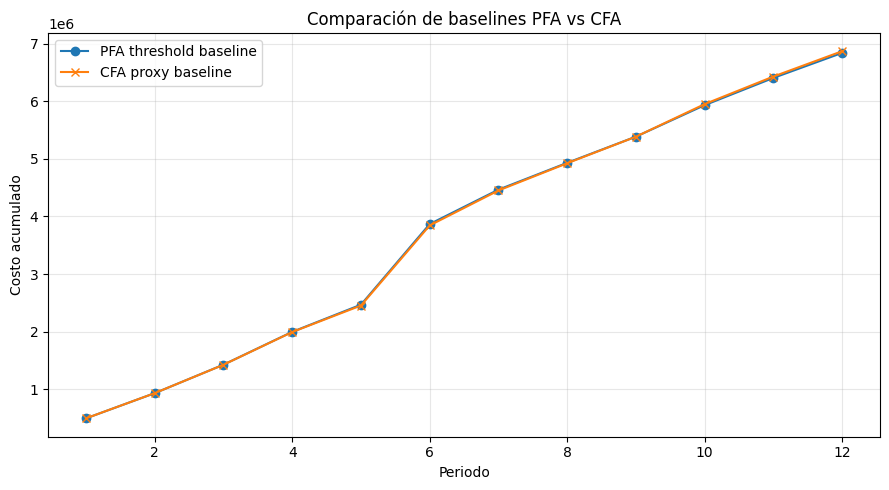

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    baseline_pfa_df["t"],
    baseline_pfa_df["cumulative_cost"],
    marker="o",
    label="PFA threshold baseline"
)

plt.plot(
    baseline_cfa_df["t"],
    baseline_cfa_df["cumulative_cost"],
    marker="x",
    label="CFA proxy baseline"
)

plt.xlabel("Periodo")
plt.ylabel("Costo acumulado")
plt.title("Comparación de baselines PFA vs CFA")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3.2 VFA — Value Function Approximation 

In [19]:
def discretize_state(state):
    """
    Estado discreto para VI y Q-learning.
    """

    failed = sum(state["failed"].values())
    reinforced = sum(state["reinforced"].values())
    budget = state["budget_remaining"]
    deficit = state["cumulative_deficit"]
    crisis = int(state["crisis"])

    failed_bin = min(failed // 10, 5)
    reinforced_bin = min(reinforced // 5, 5)

    if budget > 1500:
        budget_bin = 2
    elif budget > 500:
        budget_bin = 1
    else:
        budget_bin = 0

    if deficit == 0:
        deficit_bin = 0
    elif deficit < 500:
        deficit_bin = 1
    else:
        deficit_bin = 2

    return (crisis, failed_bin, reinforced_bin, budget_bin, deficit_bin)

In [20]:
ACTION_NAMES = [
    "do_nothing",
    "repair_failed",
    "reinforce_low_capacity",
    "repair_and_reinforce"
]

In [21]:
def build_action(action_name, state, W, nodes, edges, H_e, max_edges=3):
    """
    Construye una acción completa con 4 decisiones:
    - reinforce
    - repair
    - flow
    - generation_dispatch
    """

    edges_list = edges["e_id"].astype(int).tolist()
    nodes_list = nodes["node"].astype(int).tolist()

    action = {
        "reinforce": {e: 0 for e in edges_list},
        "repair": {e: 0 for e in edges_list},
        "flow": {e: 0.0 for e in edges_list},
        "generation_dispatch": {i: 0.0 for i in nodes_list}
    }

    # Generación despachada: usa toda la generación disponible
    for i in nodes_list:
        action["generation_dispatch"][i] = W["G"].get(i, 0.0)

    # Flujo simple: permite flujo proporcional a capacidad disponible
    # Nota: la transición luego valida capacidad y no negatividad.
    for e in edges_list:
        if state["failed"].get(e, 0) == 0:
            action["flow"][e] = 0.25 * state["capacity"].get(e, 0.0)

    if action_name == "do_nothing":
        return action

    if action_name in ["repair_failed", "repair_and_reinforce"]:
        failed_edges = [
            e for e in edges_list
            if state["failed"].get(e, 0) == 1
        ]

        for e in failed_edges[:max_edges]:
            action["repair"][e] = 1

    if action_name in ["reinforce_low_capacity", "repair_and_reinforce"]:
        candidate_edges = [
            e for e in edges_list
            if state["reinforced"].get(e, 0) == 0
        ]

        candidate_edges = sorted(
            candidate_edges,
            key=lambda e: state["capacity"].get(e, 0.0)
        )

        for e in candidate_edges[:max_edges]:
            action["reinforce"][e] = 1

    return action

In [22]:
def representative_state_from_discrete(s_disc, nodes, edges, budget=2000.0):
    """
    Construye un estado continuo representativo para un estado discreto.
    """

    state = initialize_state(nodes, edges, budget=budget)

    crisis, failed_bin, reinforced_bin, budget_bin, deficit_bin = s_disc

    edges_list = edges["e_id"].astype(int).tolist()

    # Fallas representativas
    n_failed = failed_bin * 10
    for e in edges_list[:n_failed]:
        state["failed"][e] = 1
        state["capacity"][e] = 0.0

    # Refuerzos representativos
    n_reinforced = reinforced_bin * 5
    for e in edges_list[:n_reinforced]:
        state["reinforced"][e] = 1

    # Presupuesto representativo
    if budget_bin == 2:
        state["budget_remaining"] = 1800
    elif budget_bin == 1:
        state["budget_remaining"] = 1000
    else:
        state["budget_remaining"] = 200

    # Déficit representativo
    if deficit_bin == 0:
        state["cumulative_deficit"] = 0
    elif deficit_bin == 1:
        state["cumulative_deficit"] = 250
    else:
        state["cumulative_deficit"] = 1000

    state["crisis"] = bool(crisis)

    return state

In [23]:
def build_W_pool(dfD_dyn, dfU_dyn, dfc_dyn, dfG_dyn, df_info_dyn, n_samples=30):
    """
    Extrae una muestra de realizaciones W para aproximar esperanza en VI.
    """

    available = df_info_dyn[["path", "t"]].drop_duplicates().head(n_samples)

    W_pool = []

    for _, r in available.iterrows():
        W = get_exogenous_info(
            path=int(r["path"]),
            t=int(r["t"]),
            dfD_dyn=dfD_dyn,
            dfU_dyn=dfU_dyn,
            dfc_dyn=dfc_dyn,
            dfG_dyn=dfG_dyn,
            df_info_dyn=df_info_dyn
        )
        W_pool.append(W)

    return W_pool

### Q-Learning

In [24]:
def epsilon_greedy_action(Q, s, epsilon=0.10):
    """
    Selección epsilon-greedy.
    """

    if np.random.rand() < epsilon:
        return np.random.choice(ACTION_NAMES)

    values = [Q.get((s, a), 0.0) for a in ACTION_NAMES]
    return ACTION_NAMES[int(np.argmin(values))]

In [25]:
def q_learning_train(
    nodes,
    edges,
    H_e,
    dfD_dyn,
    dfU_dyn,
    dfc_dyn,
    dfG_dyn,
    df_info_dyn,
    T=12,
    n_episodes=300,
    alpha=0.10,
    gamma=0.95,
    epsilon=0.20,
    budget=2000.0,
    seed=123
):
    """
    Q-learning para minimizar costos.
    """

    rng = np.random.default_rng(seed)
    Q = {}

    episode_returns = []

    available_paths = df_info_dyn["path"].unique()

    for ep in range(n_episodes):
        print(f"Episode {ep+1}/{n_episodes}...")
        path = int(rng.choice(available_paths))

        state = initialize_state(
            nodes=nodes,
            edges=edges,
            budget=budget
        )

        total_return = 0.0

        for t in range(1, T + 1):

            W = get_exogenous_info(
                path=path,
                t=t,
                dfD_dyn=dfD_dyn,
                dfU_dyn=dfU_dyn,
                dfc_dyn=dfc_dyn,
                dfG_dyn=dfG_dyn,
                df_info_dyn=df_info_dyn
            )

            s = discretize_state(state)

            if rng.random() < epsilon:
                a_name = rng.choice(ACTION_NAMES)
            else:
                values = [Q.get((s, a), 0.0) for a in ACTION_NAMES]
                a_name = ACTION_NAMES[int(np.argmin(values))]

            action = build_action(
                action_name=a_name,
                state=state,
                W=W,
                nodes=nodes,
                edges=edges,
                H_e=H_e
            )

            next_state, info = transition(
                state=state,
                action=action,
                W=W,
                nodes=nodes,
                edges=edges,
                H_e=H_e
            )

            cost = info["cost_breakdown"]["total_cost"]
            total_return += cost

            s_next = discretize_state(next_state)

            best_next = min(
                Q.get((s_next, a_next), 0.0)
                for a_next in ACTION_NAMES
            )

            old_q = Q.get((s, a_name), 0.0)

            Q[(s, a_name)] = old_q + alpha * (
                cost + gamma * best_next - old_q
            )

            state = next_state

        episode_returns.append(total_return)

        if (ep + 1) % 25 == 0:
            print(f"Episode {ep+1}/{n_episodes} | return = {total_return:.2f}")

    return Q, episode_returns

In [26]:
Q, q_returns = q_learning_train(
    nodes=nodes,
    edges=edges,
    H_e=H_e,
    dfD_dyn=dfD_dyn,
    dfU_dyn=dfU_dyn,
    dfc_dyn=dfc_dyn,
    dfG_dyn=dfG_dyn,
    df_info_dyn=df_info_dyn,
    T=12,
    n_episodes=100,   # más episodios
    alpha=0.05,        # menor tasa de aprendizaje
    gamma=0.90,        # menos peso al futuro lejano
    epsilon=0.30,      # más exploración inicial
    budget=2000.0,
    seed=2026
)

Episode 1/100...
Episode 2/100...
Episode 3/100...
Episode 4/100...
Episode 5/100...
Episode 6/100...
Episode 7/100...
Episode 8/100...
Episode 9/100...
Episode 10/100...
Episode 11/100...
Episode 12/100...
Episode 13/100...
Episode 14/100...
Episode 15/100...
Episode 16/100...
Episode 17/100...
Episode 18/100...
Episode 19/100...
Episode 20/100...
Episode 21/100...
Episode 22/100...
Episode 23/100...
Episode 24/100...
Episode 25/100...
Episode 25/100 | return = 19463090.89
Episode 26/100...
Episode 27/100...
Episode 28/100...
Episode 29/100...
Episode 30/100...
Episode 31/100...
Episode 32/100...
Episode 33/100...
Episode 34/100...
Episode 35/100...
Episode 36/100...
Episode 37/100...
Episode 38/100...
Episode 39/100...
Episode 40/100...
Episode 41/100...
Episode 42/100...
Episode 43/100...
Episode 44/100...
Episode 45/100...
Episode 46/100...
Episode 47/100...
Episode 48/100...
Episode 49/100...
Episode 50/100...
Episode 50/100 | return = 11548421.97
Episode 51/100...
Episode 52/100.

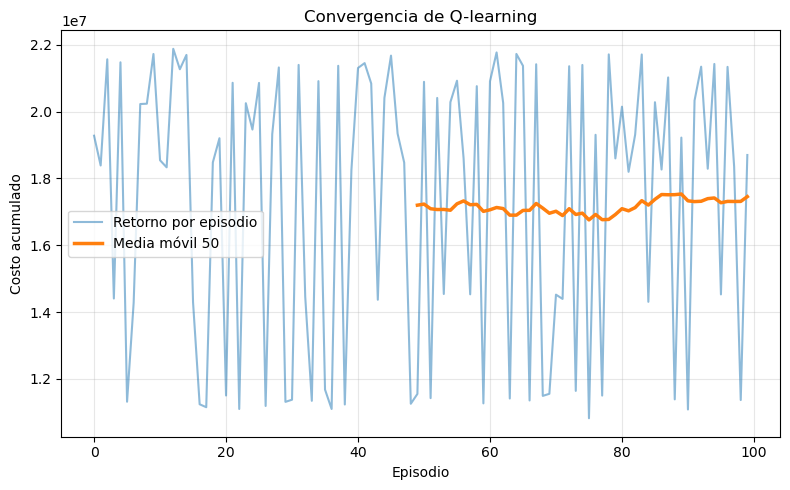

In [27]:
plt.figure(figsize=(8,5))
plt.plot(q_returns, alpha=0.5, label="Retorno por episodio")

window = 50
if len(q_returns) >= window:
    moving_avg = pd.Series(q_returns).rolling(window).mean()
    plt.plot(moving_avg, linewidth=2.5, label=f"Media móvil {window}")

plt.xlabel("Episodio")
plt.ylabel("Costo acumulado")
plt.title("Convergencia de Q-learning")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
def q_learning_policy_fn(state, W, nodes, edges, H_e, params=None):
    """
    Política greedy a partir de Q-learning.
    """

    Q = params["Q"]

    s = discretize_state(state)

    values = [Q.get((s, a), 0.0) for a in ACTION_NAMES]
    best_action_name = ACTION_NAMES[int(np.argmin(values))]

    return build_action(
        action_name=best_action_name,
        state=state,
        W=W,
        nodes=nodes,
        edges=edges,
        H_e=H_e
    )

In [29]:
episode_q = run_episode(
    policy_fn=q_learning_policy_fn,
    path=0,
    T=12,
    nodes=nodes,
    edges=edges,
    dfD_dyn=dfD_dyn,
    dfU_dyn=dfU_dyn,
    dfc_dyn=dfc_dyn,
    dfG_dyn=dfG_dyn,
    df_info_dyn=df_info_dyn,
    H_e=H_e,
    budget=2000.0,
    policy_params={"Q": Q}
)

episode_q

,path,t,crisis,budget_remaining,period_cost,operating_cost,reinforcement_cost,repair_cost,deficit_cost,total_deficit,served_demand,total_flow,total_generation_dispatch,num_failed_edges,num_reinforced_edges,action_reinforce,action_repair,cumulative_cost,cumulative_deficit
0,0,1,False,1850.0,1.527946e+06,1.067435e+06,150.0,0.0,4.603611e+05,2422.952983,900.862139,19746.75,7760.049336,4,3,"[61, 94, 96]",[],1.527946e+06,2422.952983
1,0,2,False,1625.0,1.623656e+06,1.207395e+06,150.0,75.0,4.160360e+05,2189.663089,756.300705,19699.25,7628.866382,3,6,"[102, 139, 148]","[102, 139, 148]",3.151603e+06,4612.616072
2,0,3,False,1550.0,1.643924e+06,1.185922e+06,0.0,75.0,4.579270e+05,2410.142278,910.115889,19887.95,7597.748409,3,6,[],"[39, 57, 174]",4.795527e+06,7022.758350
3,0,4,False,1475.0,1.732445e+06,1.220448e+06,0.0,75.0,5.119217e+05,2694.324866,962.445009,20083.95,7641.660269,4,6,[],"[76, 99, 138]",6.527972e+06,9717.083217
4,0,5,False,1400.0,1.594919e+06,1.172568e+06,0.0,75.0,4.222755e+05,2222.502634,793.233067,20205.95,7560.929300,2,6,[],"[31, 38, 124]",8.122891e+06,11939.585850
5,0,6,True,1350.0,3.408463e+06,2.263713e+06,0.0,50.0,1.144699e+06,6024.733696,2075.278218,17224.45,7686.697248,36,6,[],"[142, 167]",1.153135e+07,17964.319546
6,0,7,False,1275.0,1.640404e+06,1.163851e+06,0.0,75.0,4.764783e+05,2507.780415,1181.833536,17159.45,7681.694526,36,6,[],"[0, 1, 7]",1.317176e+07,20472.099962
7,0,8,False,1125.0,1.413738e+06,1.049750e+06,150.0,0.0,3.638375e+05,1914.934122,948.957416,17402.20,7637.659839,39,9,"[11, 13, 20]",[],1.458550e+07,22387.034084
8,0,9,False,975.0,1.355305e+06,9.918348e+05,150.0,0.0,3.633203e+05,1912.212264,928.273903,16021.25,7865.551006,45,12,"[27, 30, 35]",[],1.594080e+07,24299.246348
9,0,10,False,975.0,1.523292e+06,1.079564e+06,0.0,0.0,4.437283e+05,2335.411883,1088.695932,15949.75,7583.248698,46,12,[],[],1.746409e+07,26634.658231


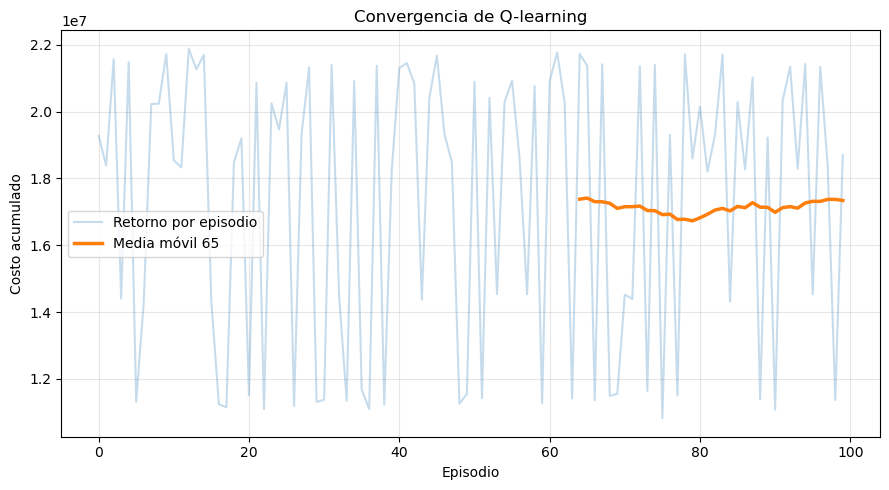

In [30]:
plt.figure(figsize=(9,5))
plt.plot(q_returns, alpha=0.25, label="Retorno por episodio")

moving_avg = pd.Series(q_returns).rolling(65).mean()
plt.plot(moving_avg, linewidth=2.5, label="Media móvil 65")

plt.xlabel("Episodio")
plt.ylabel("Costo acumulado")
plt.title("Convergencia de Q-learning")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [31]:
initial_avg = np.mean(q_returns[:50])
final_avg = np.mean(q_returns[-50:])

improvement = 100 * (initial_avg - final_avg) / initial_avg

print("Promedio inicial:", initial_avg)
print("Promedio final:", final_avg)
print("Mejora (%):", improvement)

Promedio inicial: 17198953.30171518
Promedio final: 17454984.410401836
Mejora (%): -1.488643548215942


In [ ]:
policy_rows = []

for s in sorted(set([key[0] for key in Q.keys()])):
    values = {a: Q.get((s, a), 0.0) for a in ACTION_NAMES}
    best_action = min(values, key=values.get)

    policy_rows.append({
        "crisis": s[0],
        "failed_bin": s[1],
        "reinforced_bin": s[2],
        "budget_bin": s[3],
        "deficit_bin": s[4],
        "best_action": best_action,
        **values
    })

policy_df = pd.DataFrame(policy_rows)
policy_df.head()

,crisis,failed_bin,reinforced_bin,budget_bin,deficit_bin,best_action,do_nothing,repair_failed,reinforce_low_capacity,repair_and_reinforce
0,0,0,0,2,0,reinforce_low_capacity,2.317053e+06,2.403746e+06,2.284981e+06,2.358065e+06
1,0,0,0,2,2,repair_and_reinforce,2.769453e+06,2.749610e+06,2.721900e+06,2.721208e+06
2,0,0,1,1,2,repair_failed,8.842100e+05,8.652338e+05,9.859068e+05,9.539192e+05
3,0,0,1,2,2,repair_failed,1.529474e+06,1.526357e+06,1.540994e+06,1.546948e+06
4,0,0,2,1,2,do_nothing,4.848613e+05,6.240454e+05,4.851382e+05,5.880290e+05


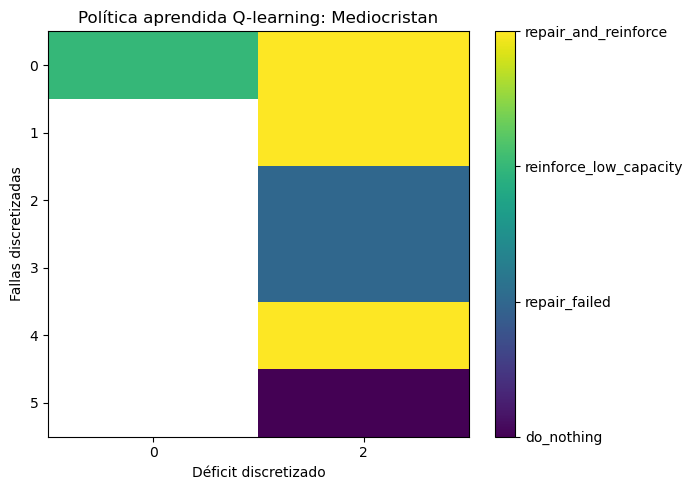

In [33]:
action_to_num = {a: i for i, a in enumerate(ACTION_NAMES)}

df_plot = policy_df.copy()
df_plot["action_num"] = df_plot["best_action"].map(action_to_num)

# Fijamos crisis=0, presupuesto alto, refuerzos bajos
subset = df_plot[
    (df_plot["crisis"] == 0) &
    (df_plot["budget_bin"] == 2) &
    (df_plot["reinforced_bin"] == 0)
]

pivot = subset.pivot_table(
    index="failed_bin",
    columns="deficit_bin",
    values="action_num",
    aggfunc="first"
)

plt.figure(figsize=(7,5))
plt.imshow(pivot, aspect="auto")

plt.xticks(
    ticks=np.arange(len(pivot.columns)),
    labels=pivot.columns
)
plt.yticks(
    ticks=np.arange(len(pivot.index)),
    labels=pivot.index
)

plt.xlabel("Déficit discretizado")
plt.ylabel("Fallas discretizadas")
plt.title("Política aprendida Q-learning: Mediocristan")

cbar = plt.colorbar()
cbar.set_ticks(list(action_to_num.values()))
cbar.set_ticklabels(list(action_to_num.keys()))

plt.tight_layout()
plt.show()

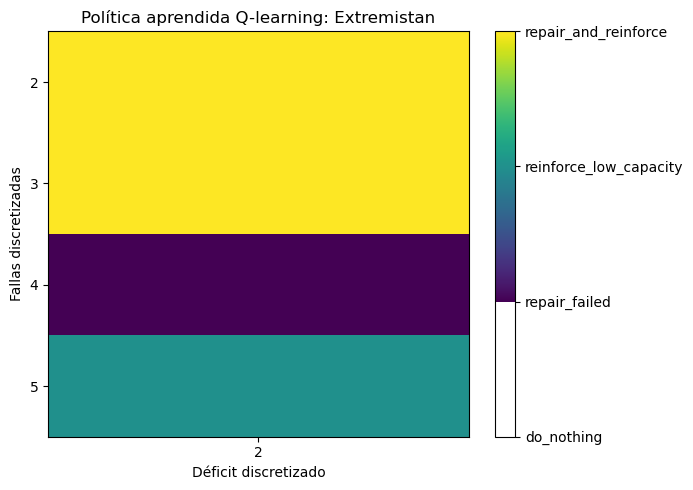

In [34]:
subset = df_plot[
    (df_plot["crisis"] == 1) &
    (df_plot["budget_bin"] == 2) &
    (df_plot["reinforced_bin"] == 0)
]

pivot = subset.pivot_table(
    index="failed_bin",
    columns="deficit_bin",
    values="action_num",
    aggfunc="first"
)

plt.figure(figsize=(7,5))
plt.imshow(pivot, aspect="auto")

plt.xticks(np.arange(len(pivot.columns)), pivot.columns)
plt.yticks(np.arange(len(pivot.index)), pivot.index)

plt.xlabel("Déficit discretizado")
plt.ylabel("Fallas discretizadas")
plt.title("Política aprendida Q-learning: Extremistan")

cbar = plt.colorbar()
cbar.set_ticks(list(action_to_num.values()))
cbar.set_ticklabels(list(action_to_num.keys()))

plt.tight_layout()
plt.show()

## Evaluación

In [50]:
dfD_dyn, dfU_dyn, dfc_dyn, dfG_dyn, df_info_dyn  = generate_dynamic_scenarios(
    nodes=nodes,
    edges=edges,
    T=20,
    n_paths=10,
    seed=2026,
    p_crisis=0.15
)

df_info_dyn 

,path,t,crisis,dem_mult,cost_mult
0,0,1,False,1.024057,0.905184
1,0,2,False,0.907642,1.024866
2,0,3,False,1.022961,1.005959
3,0,4,False,1.126639,1.028948
4,0,5,False,0.929139,0.987031
...,...,...,...,...,...
195,9,16,False,0.925201,1.025112
196,9,17,True,1.629118,2.000000
197,9,18,False,0.745267,0.965889
198,9,19,True,1.912013,2.000000


In [51]:
path_summary = (
    df_info_dyn
    .groupby("path")
    .agg(
        crisis_share=("crisis", "mean"),
        n_periods=("t", "count")
    )
    .reset_index()
)

paths_med = path_summary.loc[
    path_summary["crisis_share"] <= 0.10,
    "path"
].tolist()

paths_ext = path_summary.loc[
    path_summary["crisis_share"] > 0.10,
    "path"
].tolist()

paths_mix = path_summary["path"].tolist()

print("Paths mix:", len(paths_mix))
print("Paths Mediocristan:", len(paths_med))
print("Paths Extremistan:", len(paths_ext))

Paths mix: 10
Paths Mediocristan: 6
Paths Extremistan: 4


In [52]:
df_info_mix = df_info_dyn[df_info_dyn["path"].isin(paths_mix)].copy()
df_info_med = df_info_dyn[df_info_dyn["path"].isin(paths_med)].copy()
df_info_ext = df_info_dyn[df_info_dyn["path"].isin(paths_ext)].copy()

print("Filas mix:", len(df_info_mix))
print("Filas med:", len(df_info_med))
print("Filas ext:", len(df_info_ext))

Filas mix: 200
Filas med: 120
Filas ext: 80


In [53]:
T_MODEL = 20
N_PATHS = 10


In [54]:
# ============================================================
# Política 1: entrenada con mezcla de escenarios
# ============================================================

Q_mix, returns_mix  = q_learning_train(
    nodes=nodes,
    edges=edges,
    H_e=H_e,
    dfD_dyn=dfD_dyn,
    dfU_dyn=dfU_dyn,
    dfc_dyn=dfc_dyn,
    dfG_dyn=dfG_dyn,
    df_info_dyn=df_info_mix,
    T=T_MODEL,
    n_episodes=1200,   # más episodios
    alpha=0.05,        # menor tasa de aprendizaje
    gamma=0.90,        # menos peso al futuro lejano
    epsilon=0.30,      # más exploración inicial
    budget=2000.0,
    seed=2026
)

Episode 1/1200...
Episode 2/1200...
Episode 3/1200...
Episode 4/1200...
Episode 5/1200...
Episode 6/1200...
Episode 7/1200...
Episode 8/1200...
Episode 9/1200...
Episode 10/1200...
Episode 11/1200...
Episode 12/1200...
Episode 13/1200...
Episode 14/1200...
Episode 15/1200...
Episode 16/1200...
Episode 17/1200...
Episode 18/1200...
Episode 19/1200...
Episode 20/1200...
Episode 21/1200...
Episode 22/1200...
Episode 23/1200...
Episode 24/1200...
Episode 25/1200...
Episode 25/1200 | return = 30216977.04
Episode 26/1200...
Episode 27/1200...
Episode 28/1200...
Episode 29/1200...
Episode 30/1200...
Episode 31/1200...
Episode 32/1200...
Episode 33/1200...
Episode 34/1200...
Episode 35/1200...
Episode 36/1200...
Episode 37/1200...
Episode 38/1200...
Episode 39/1200...
Episode 40/1200...
Episode 41/1200...
Episode 42/1200...
Episode 43/1200...
Episode 44/1200...
Episode 45/1200...
Episode 46/1200...
Episode 47/1200...
Episode 48/1200...
Episode 49/1200...
Episode 50/1200...
Episode 50/1200 | re

In [55]:
# ============================================================
# Política 2: entrenada solo con Mediocristan
# ============================================================

Q_med, returns_med = q_learning_train(
    nodes=nodes,
    edges=edges,
    H_e=H_e,
    dfD_dyn=dfD_dyn,
    dfU_dyn=dfU_dyn,
    dfc_dyn=dfc_dyn,
    dfG_dyn=dfG_dyn,
    df_info_dyn=df_info_med,
    T=T_MODEL,
    n_episodes=1200,
    alpha=0.05,
    gamma=0.90,
    epsilon=0.30,
    budget=2000.0,
    seed=2027
)

Episode 1/1200...
Episode 2/1200...
Episode 3/1200...
Episode 4/1200...
Episode 5/1200...
Episode 6/1200...
Episode 7/1200...
Episode 8/1200...
Episode 9/1200...
Episode 10/1200...
Episode 11/1200...
Episode 12/1200...
Episode 13/1200...
Episode 14/1200...
Episode 15/1200...
Episode 16/1200...
Episode 17/1200...
Episode 18/1200...
Episode 19/1200...
Episode 20/1200...
Episode 21/1200...
Episode 22/1200...
Episode 23/1200...
Episode 24/1200...
Episode 25/1200...
Episode 25/1200 | return = 23070115.19
Episode 26/1200...
Episode 27/1200...
Episode 28/1200...
Episode 29/1200...
Episode 30/1200...
Episode 31/1200...
Episode 32/1200...
Episode 33/1200...
Episode 34/1200...
Episode 35/1200...
Episode 36/1200...
Episode 37/1200...
Episode 38/1200...
Episode 39/1200...
Episode 40/1200...
Episode 41/1200...
Episode 42/1200...
Episode 43/1200...
Episode 44/1200...
Episode 45/1200...
Episode 46/1200...
Episode 47/1200...
Episode 48/1200...
Episode 49/1200...
Episode 50/1200...
Episode 50/1200 | re

In [56]:
# ============================================================
# Política 3: entrenada solo con Extremistan
# ============================================================

Q_ext, returns_ext = q_learning_train(
    nodes=nodes,
    edges=edges,
    H_e=H_e,
    dfD_dyn=dfD_dyn,
    dfU_dyn=dfU_dyn,
    dfc_dyn=dfc_dyn,
    dfG_dyn=dfG_dyn,
    df_info_dyn=df_info_ext,
    T=T_MODEL,
    n_episodes=1200,
    alpha=0.05,
    gamma=0.90,
    epsilon=0.30,
    budget=2000.0,
    seed=2028
)

Episode 1/1200...
Episode 2/1200...
Episode 3/1200...
Episode 4/1200...
Episode 5/1200...
Episode 6/1200...
Episode 7/1200...
Episode 8/1200...
Episode 9/1200...
Episode 10/1200...
Episode 11/1200...
Episode 12/1200...
Episode 13/1200...
Episode 14/1200...
Episode 15/1200...
Episode 16/1200...
Episode 17/1200...
Episode 18/1200...
Episode 19/1200...
Episode 20/1200...
Episode 21/1200...
Episode 22/1200...
Episode 23/1200...
Episode 24/1200...
Episode 25/1200...
Episode 25/1200 | return = 22197285.46
Episode 26/1200...
Episode 27/1200...
Episode 28/1200...
Episode 29/1200...
Episode 30/1200...
Episode 31/1200...
Episode 32/1200...
Episode 33/1200...
Episode 34/1200...
Episode 35/1200...
Episode 36/1200...
Episode 37/1200...
Episode 38/1200...
Episode 39/1200...
Episode 40/1200...
Episode 41/1200...
Episode 42/1200...
Episode 43/1200...
Episode 44/1200...
Episode 45/1200...
Episode 46/1200...
Episode 47/1200...
Episode 48/1200...
Episode 49/1200...
Episode 50/1200...
Episode 50/1200 | re

### Convergencias Comparadas

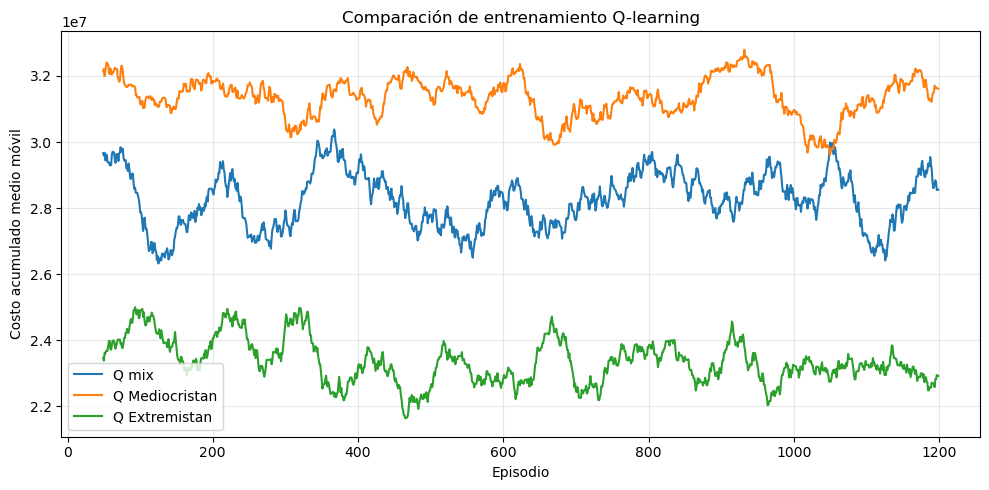

In [57]:
plt.figure(figsize=(10, 5))

window = 50

plt.plot(pd.Series(returns_mix).rolling(window).mean(), label="Q mix")
plt.plot(pd.Series(returns_med).rolling(window).mean(), label="Q Mediocristan")
plt.plot(pd.Series(returns_ext).rolling(window).mean(), label="Q Extremistan")

plt.xlabel("Episodio")
plt.ylabel("Costo acumulado medio móvil")
plt.title("Comparación de entrenamiento Q-learning")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [58]:
def make_q_policy(Q_table):
    def policy_fn(state, W, nodes, edges, H_e, params=None):
        return q_learning_policy_fn(
            state=state,
            W=W,
            nodes=nodes,
            edges=edges,
            H_e=H_e,
            params={"Q": Q_table}
        )
    return policy_fn


policy_mix = make_q_policy(Q_mix)
policy_med = make_q_policy(Q_med)
policy_ext = make_q_policy(Q_ext)

In [59]:
def evaluate_policy_on_paths(
    policy_fn,
    policy_name,
    paths,
    T,
    nodes,
    edges,
    dfD_dyn,
    dfU_dyn,
    dfc_dyn,
    dfG_dyn,
    df_info_dyn,
    H_e,
    budget=2000.0
):
    rows = []

    for path in paths:
        ep = run_episode(
            policy_fn=policy_fn,
            path=int(path),
            T=T,
            nodes=nodes,
            edges=edges,
            dfD_dyn=dfD_dyn,
            dfU_dyn=dfU_dyn,
            dfc_dyn=dfc_dyn,
            dfG_dyn=dfG_dyn,
            df_info_dyn=df_info_dyn,
            H_e=H_e,
            budget=budget
        )

        rows.append({
            "policy": policy_name,
            "path": int(path),
            "total_cost": ep["period_cost"].sum(),
            "total_deficit": ep["total_deficit"].sum(),
            "final_budget": ep["budget_remaining"].iloc[-1],
            "max_failed_edges": ep["num_failed_edges"].max(),
            "final_reinforced": ep["num_reinforced_edges"].iloc[-1],
            "crisis_share": ep["crisis"].mean()
        })

    return pd.DataFrame(rows)

In [60]:
eval_all = pd.concat([
    evaluate_policy_on_paths(policy_mix, "Q_mix", paths_mix, T_MODEL, nodes, edges, dfD_dyn, dfU_dyn, dfc_dyn, dfG_dyn, df_info_dyn, H_e),
    evaluate_policy_on_paths(policy_med, "Q_med", paths_mix, T_MODEL, nodes, edges, dfD_dyn, dfU_dyn, dfc_dyn, dfG_dyn, df_info_dyn, H_e),
    evaluate_policy_on_paths(policy_ext, "Q_ext", paths_mix, T_MODEL, nodes, edges, dfD_dyn, dfU_dyn, dfc_dyn, dfG_dyn, df_info_dyn, H_e),
], ignore_index=True)

eval_all.head()

,policy,path,total_cost,total_deficit,final_budget,max_failed_edges,final_reinforced,crisis_share
0,Q_mix,0,3.445535e+07,52033.093893,0.0,56,15,0.10
1,Q_mix,1,2.324490e+07,51915.246494,0.0,80,24,0.10
2,Q_mix,2,2.317570e+07,54931.612141,650.0,92,3,0.15
3,Q_mix,3,2.938355e+07,52761.530652,650.0,125,24,0.15
4,Q_mix,4,3.406211e+07,49769.733460,0.0,62,27,0.05


In [61]:
summary_q_policies = (
    eval_all
    .groupby("policy")
    .agg(
        costo_promedio=("total_cost", "mean"),
        costo_p95=("total_cost", lambda x: np.percentile(x, 95)),
        costo_max=("total_cost", "max"),
        deficit_promedio=("total_deficit", "mean"),
        presupuesto_final_promedio=("final_budget", "mean"),
        refuerzos_finales_promedio=("final_reinforced", "mean")
    )
    .reset_index()
)

summary_q_policies

,policy,costo_promedio,costo_p95,costo_max,deficit_promedio,presupuesto_final_promedio,refuerzos_finales_promedio
0,Q_ext,2.800993e+07,3.442005e+07,3.446322e+07,52170.126388,177.5,25.2
1,Q_med,2.769915e+07,3.393917e+07,3.396489e+07,52895.624083,1295.0,6.9
2,Q_mix,2.822382e+07,3.470211e+07,3.490401e+07,52682.967550,232.5,19.5


C:\Users\Usuario\AppData\Local\Temp\ipykernel_5616\920273333.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=eval_all["policy"].unique(), showmeans=True)


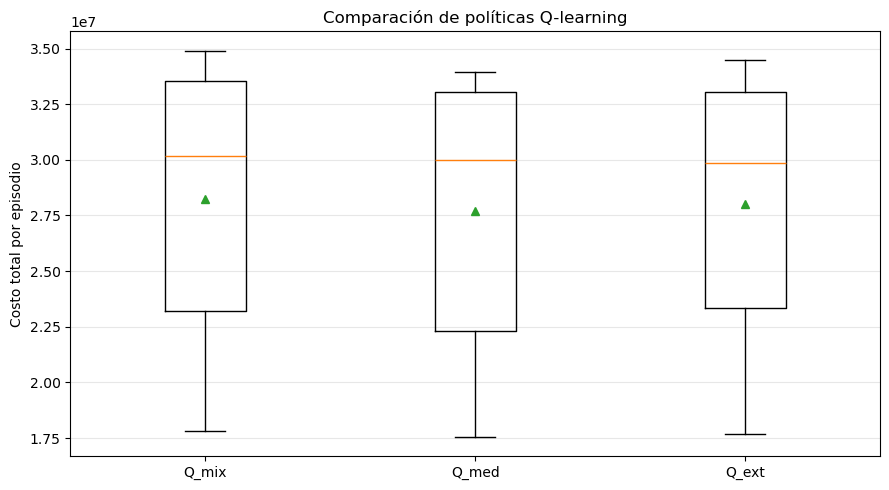

In [62]:
plt.figure(figsize=(9, 5))

data = [
    eval_all.loc[eval_all["policy"] == p, "total_cost"].values
    for p in eval_all["policy"].unique()
]

plt.boxplot(data, labels=eval_all["policy"].unique(), showmeans=True)

plt.ylabel("Costo total por episodio")
plt.title("Comparación de políticas Q-learning")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [72]:
def compute_learning_improvement(returns, window=50, policy_name="Q"):
    initial_avg = np.mean(returns[:window])
    final_avg = np.mean(returns[-window:])

    improvement = 100 * (initial_avg - final_avg) / initial_avg

    return {
        "Política": policy_name,
        "Promedio inicial": initial_avg,
        "Promedio final": final_avg,
        "Mejora (%)": improvement
    }


improvement_table = pd.DataFrame([
    compute_learning_improvement(returns_mix, window=75, policy_name="Q_mix"),
    compute_learning_improvement(returns_med, window=75, policy_name="Q_med"),
    compute_learning_improvement(returns_ext, window=75, policy_name="Q_ext")
])

improvement_table
improvement_table_fmt = improvement_table.copy()

for col in ["Promedio inicial", "Promedio final", "Mejora (%)"]:
    improvement_table_fmt[col] = improvement_table_fmt[col].map(lambda x: f"{x:,.2f}")

improvement_table_fmt

,Política,Promedio inicial,Promedio final,Mejora (%)
0,Q_mix,"29,486,544.02","28,573,325.50",3.10
1,Q_med,"31,822,356.48","31,769,034.61",0.17
2,Q_ext,"23,873,068.46","22,954,496.57",3.85


In [64]:
def build_policy_df_from_Q(Q, policy_name="Q"):
    """
    Convierte una Q-table en una tabla de política greedy.
    Compatible con el estado:
    (crisis, failed_bin, reinforced_bin, budget_bin, deficit_bin)
    """

    rows = []
    visited_states = sorted({s for (s, a) in Q.keys()})

    for s in visited_states:
        values = [Q.get((s, a), 0.0) for a in ACTION_NAMES]
        best_action = ACTION_NAMES[int(np.argmin(values))]

        crisis, failed_bin, reinforced_bin, budget_bin, deficit_bin = s

        rows.append({
            "policy": policy_name,
            "crisis": crisis,
            "failed_bin": failed_bin,
            "reinforced_bin": reinforced_bin,
            "budget_bin": budget_bin,
            "deficit_bin": deficit_bin,
            "best_action": best_action
        })

    return pd.DataFrame(rows)

In [65]:
def plot_q_heatmap(
    Q,
    policy_name,
    crisis_value=0,
    budget_bin=2,
    reinforced_bin=0
):
    """
    Heatmap de decisiones aprendidas.
    """

    policy_df = build_policy_df_from_Q(Q, policy_name=policy_name)

    action_to_num = {a: i for i, a in enumerate(ACTION_NAMES)}
    num_to_action = {i: a for a, i in action_to_num.items()}

    df_plot = policy_df.copy()
    df_plot["action_num"] = df_plot["best_action"].map(action_to_num)

    subset = df_plot[
        (df_plot["crisis"] == crisis_value) &
        (df_plot["budget_bin"] == budget_bin) &
        (df_plot["reinforced_bin"] == reinforced_bin)
    ]

    pivot = subset.pivot_table(
        index="failed_bin",
        columns="deficit_bin",
        values="action_num",
        aggfunc="first"
    )

    pivot = pivot.reindex(
        index=sorted(policy_df["failed_bin"].unique()),
        columns=sorted(policy_df["deficit_bin"].unique())
    )

    data = np.ma.masked_invalid(pivot.values)

    cmap = ListedColormap([
        "#2E3440",
        "#5E81AC",
        "#A3BE8C",
        "#EBCB8B",
        "#BF616A",
        "#B48EAD"
    ][:len(ACTION_NAMES)])

    cmap.set_bad(color="#E5E9F0")

    norm = BoundaryNorm(
        boundaries=np.arange(-0.5, len(ACTION_NAMES) + 0.5, 1),
        ncolors=len(ACTION_NAMES)
    )

    regime = "Mediocristan" if crisis_value == 0 else "Extremistan"

    plt.figure(figsize=(8.5, 5.5))
    im = plt.imshow(data, aspect="auto", cmap=cmap, norm=norm)

    plt.xticks(
        ticks=np.arange(len(pivot.columns)),
        labels=pivot.columns
    )

    plt.yticks(
        ticks=np.arange(len(pivot.index)),
        labels=pivot.index
    )

    plt.xlabel("Déficit acumulado discretizado")
    plt.ylabel("Fallas discretizadas")
    plt.title(f"{policy_name} | Política aprendida en {regime}")

    cbar = plt.colorbar(im)
    cbar.set_ticks(list(action_to_num.values()))
    cbar.set_ticklabels([num_to_action[i] for i in range(len(ACTION_NAMES))])

    plt.tight_layout()
    plt.show()

    print(f"\nResumen acciones {policy_name} - {regime}")
    print(subset["best_action"].value_counts())

In [66]:
def get_episode_actions_summary(episode_df):
    """
    Extrae arcos reforzados y reparados durante un episodio.
    """

    reinforced = []
    repaired = []

    for _, row in episode_df.iterrows():
        reinforced += row["action_reinforce"]
        repaired += row["action_repair"]

    reinforced = sorted(list(set(reinforced)))
    repaired = sorted(list(set(repaired)))

    return reinforced, repaired

In [67]:
episode_mix = run_episode(
    policy_fn=policy_mix,
    path=0,
    T=T_MODEL,
    nodes=nodes,
    edges=edges,
    dfD_dyn=dfD_dyn,
    dfU_dyn=dfU_dyn,
    dfc_dyn=dfc_dyn,
    dfG_dyn=dfG_dyn,
    df_info_dyn=df_info_dyn,
    H_e=H_e,
    budget=2000.0
)

episode_med = run_episode(
    policy_fn=policy_med,
    path=0,
    T=T_MODEL,
    nodes=nodes,
    edges=edges,
    dfD_dyn=dfD_dyn,
    dfU_dyn=dfU_dyn,
    dfc_dyn=dfc_dyn,
    dfG_dyn=dfG_dyn,
    df_info_dyn=df_info_dyn,
    H_e=H_e,
    budget=2000.0
)

episode_ext = run_episode(
    policy_fn=policy_ext,
    path=0,
    T=T_MODEL,
    nodes=nodes,
    edges=edges,
    dfD_dyn=dfD_dyn,
    dfU_dyn=dfU_dyn,
    dfc_dyn=dfc_dyn,
    dfG_dyn=dfG_dyn,
    df_info_dyn=df_info_dyn,
    H_e=H_e,
    budget=2000.0
)

In [68]:
def plot_policy_network(
    nodes,
    edges,
    episode_df,
    title="Red con decisiones de política",
    figsize=(12, 9),
    seed=7
):
    """
    Grafica la red resaltando:
    - arcos reforzados
    - arcos reparados
    - arcos fallados finales
    - generadores
    """

    reinforced_edges, repaired_edges = get_episode_actions_summary(episode_df)

    final_failed_count = episode_df["num_failed_edges"].iloc[-1]
    final_reinforced_count = episode_df["num_reinforced_edges"].iloc[-1]

    G = nx.Graph()

    for _, r in nodes.iterrows():
        node = int(r["node"])
        is_gen = bool(r.get("is_generator", False))
        G.add_node(node, is_generator=is_gen)

    edge_id_to_pair = {}

    for _, r in edges.iterrows():
        e = int(r["e_id"])
        i = int(r["i"])
        j = int(r["j"])
        G.add_edge(i, j, e_id=e)
        edge_id_to_pair[e] = (i, j)

    pos = nx.spring_layout(G, seed=seed, k=0.18)

    gen_nodes = [
        n for n, attr in G.nodes(data=True)
        if attr.get("is_generator", False)
    ]

    demand_nodes = [
        n for n in G.nodes()
        if n not in gen_nodes
    ]

    normal_edges = []
    reinforced_plot_edges = []
    repaired_plot_edges = []
    both_edges = []

    for e, pair in edge_id_to_pair.items():
        is_reinf = e in reinforced_edges
        is_rep = e in repaired_edges

        if is_reinf and is_rep:
            both_edges.append(pair)
        elif is_reinf:
            reinforced_plot_edges.append(pair)
        elif is_rep:
            repaired_plot_edges.append(pair)
        else:
            normal_edges.append(pair)

    plt.figure(figsize=figsize)

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=normal_edges,
        alpha=0.18,
        width=0.8
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=reinforced_plot_edges,
        width=2.8,
        edge_color="#D62728",
        label="Reforzado"
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=repaired_plot_edges,
        width=2.8,
        edge_color="#1F77B4",
        style="dashed",
        label="Reparado"
    )

    nx.draw_networkx_edges(
        G,
        pos,
        edgelist=both_edges,
        width=3.2,
        edge_color="#9467BD",
        style="dashdot",
        label="Reforzado y reparado"
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=demand_nodes,
        node_size=55,
        node_color="#D8DEE9",
        edgecolors="#4C566A",
        linewidths=0.4,
        label="Nodos"
    )

    nx.draw_networkx_nodes(
        G,
        pos,
        nodelist=gen_nodes,
        node_size=130,
        node_color="#A3BE8C",
        edgecolors="#2E3440",
        linewidths=0.8,
        label="Generadores"
    )

    plt.title(
        f"{title}\n"
        f"Reforzados: {len(reinforced_edges)} | "
        f"Reparados: {len(repaired_edges)} | "
        f"Fallas finales: {final_failed_count} | "
        f"Refuerzos finales: {final_reinforced_count}",
        fontsize=13
    )

    plt.axis("off")
    plt.legend(loc="lower left", frameon=True)
    plt.tight_layout()
    plt.show()

    print("Arcos reforzados:", reinforced_edges)
    print("Arcos reparados:", repaired_edges)

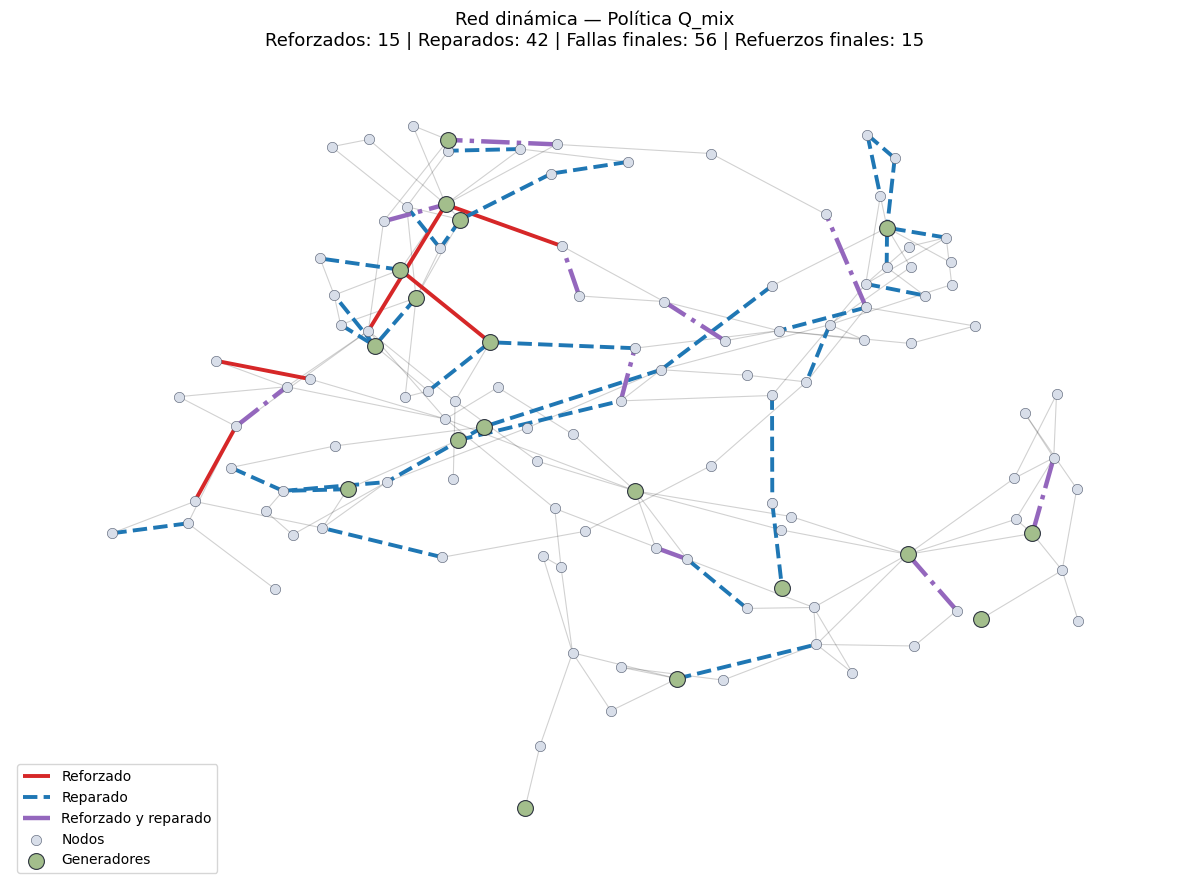

Arcos reforzados: [49, 50, 53, 55, 57, 60, 61, 94, 96, 102, 139, 142, 148, 167, 174]
Arcos reparados: [0, 1, 4, 6, 7, 10, 11, 13, 20, 24, 27, 30, 31, 34, 35, 38, 39, 46, 49, 50, 53, 55, 57, 60, 67, 68, 70, 72, 76, 81, 82, 84, 86, 87, 91, 99, 102, 124, 138, 139, 142, 148]


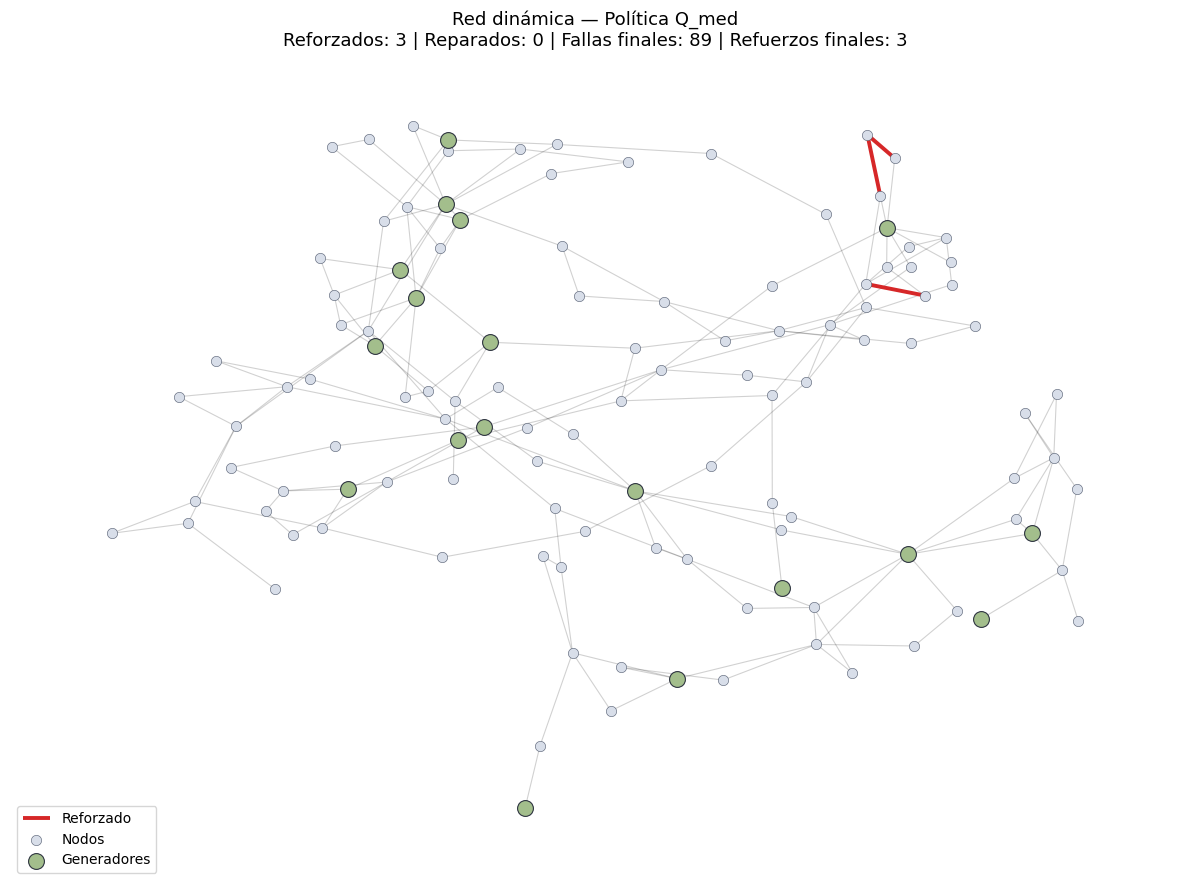

Arcos reforzados: [0, 1, 4]
Arcos reparados: []


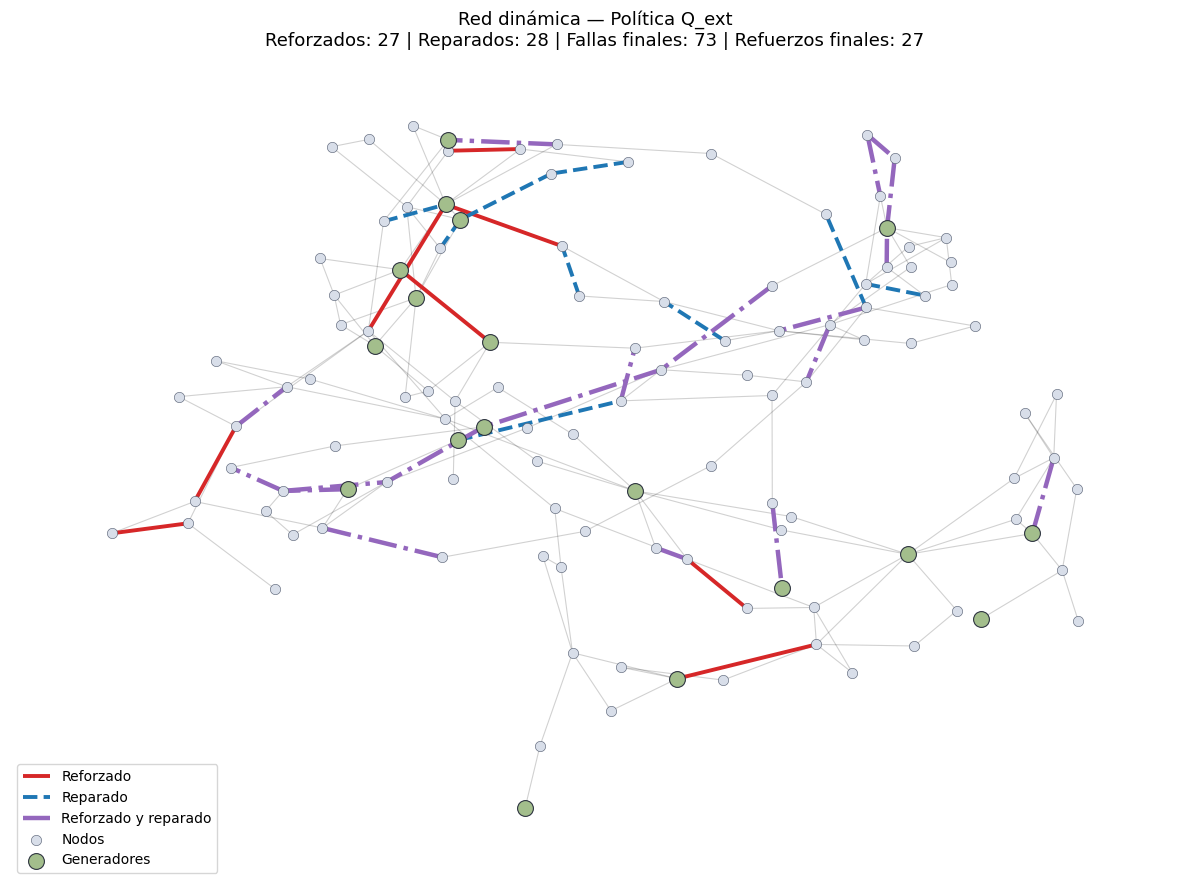

Arcos reforzados: [0, 1, 7, 11, 13, 20, 24, 27, 30, 31, 35, 38, 39, 46, 49, 57, 61, 76, 94, 96, 99, 102, 124, 138, 139, 148, 174]
Arcos reparados: [0, 1, 4, 7, 11, 13, 20, 24, 27, 30, 31, 34, 35, 38, 39, 46, 49, 50, 53, 55, 57, 60, 67, 68, 70, 102, 139, 148]


In [69]:
plot_policy_network(
    nodes=nodes,
    edges=edges,
    episode_df=episode_mix,
    title="Red dinámica — Política Q_mix"
)

plot_policy_network(
    nodes=nodes,
    edges=edges,
    episode_df=episode_med,
    title="Red dinámica — Política Q_med"
)

plot_policy_network(
    nodes=nodes,
    edges=edges,
    episode_df=episode_ext,
    title="Red dinámica — Política Q_ext"
)

In [70]:
def plot_episode_comparison(episodes_dict):
    """
    Compara costo acumulado y déficit acumulado.
    """

    plt.figure(figsize=(9, 5))

    for name, ep in episodes_dict.items():
        plt.plot(
            ep["t"],
            ep["cumulative_cost"],
            marker="o",
            linewidth=2,
            label=name
        )

    plt.xlabel("Periodo")
    plt.ylabel("Costo acumulado")
    plt.title("Costo acumulado por política")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 5))

    for name, ep in episodes_dict.items():
        plt.plot(
            ep["t"],
            ep["cumulative_deficit"],
            marker="o",
            linewidth=2,
            label=name
        )

    plt.xlabel("Periodo")
    plt.ylabel("Déficit acumulado")
    plt.title("Déficit acumulado por política")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

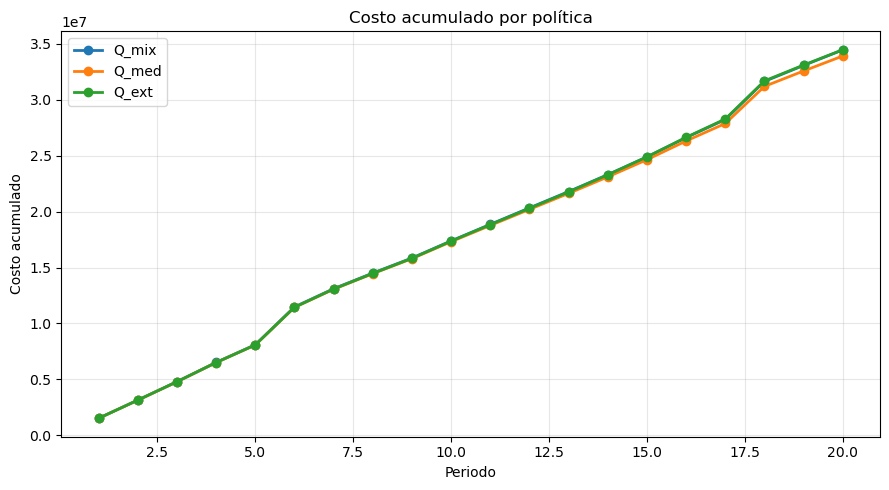

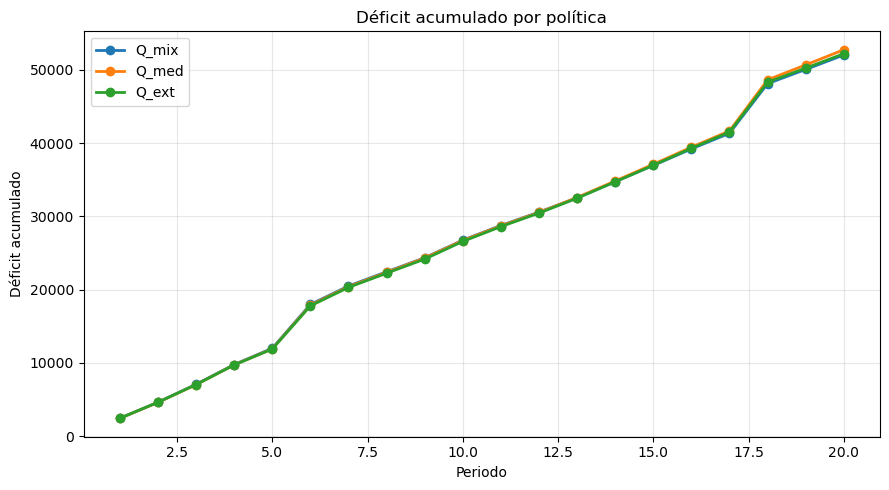

In [71]:
plot_episode_comparison({
    "Q_mix": episode_mix,
    "Q_med": episode_med,
    "Q_ext": episode_ext
})

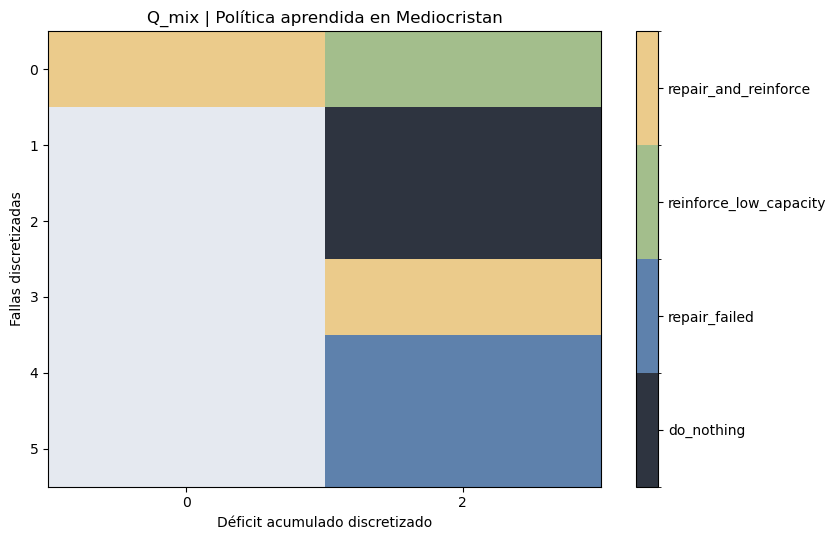


Resumen acciones Q_mix - Mediocristan
best_action
repair_and_reinforce      2
do_nothing                2
repair_failed             2
reinforce_low_capacity    1
Name: count, dtype: int64


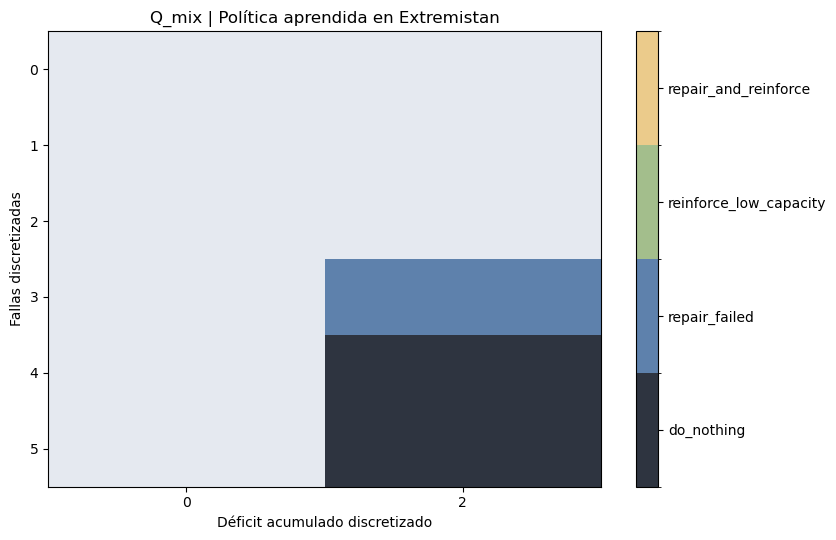


Resumen acciones Q_mix - Extremistan
best_action
do_nothing       2
repair_failed    1
Name: count, dtype: int64


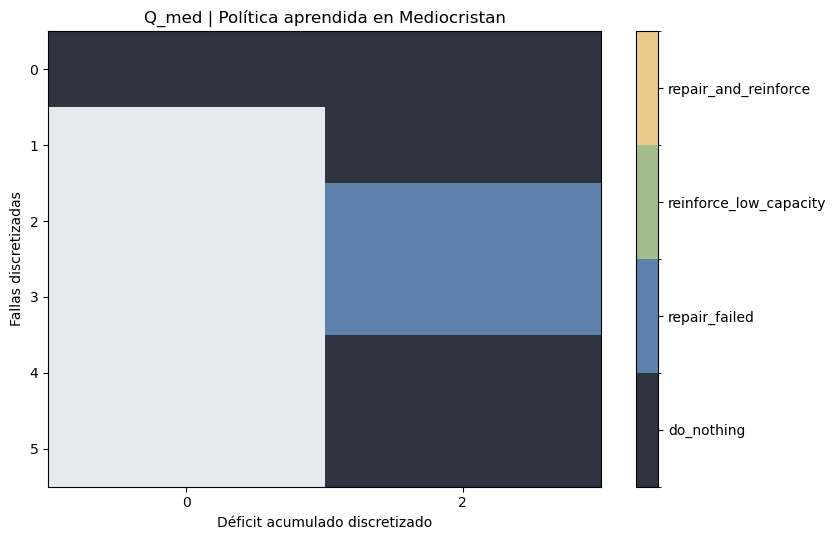


Resumen acciones Q_med - Mediocristan
best_action
do_nothing       5
repair_failed    2
Name: count, dtype: int64


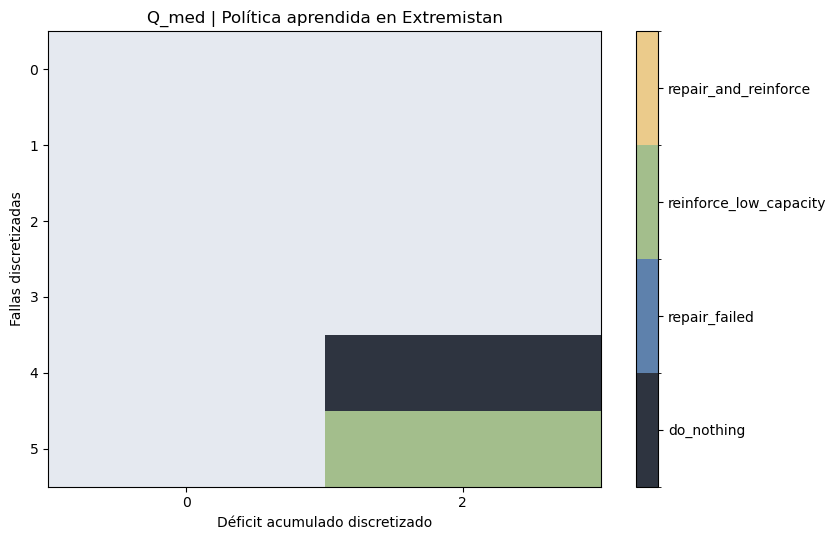


Resumen acciones Q_med - Extremistan
best_action
do_nothing                1
reinforce_low_capacity    1
Name: count, dtype: int64


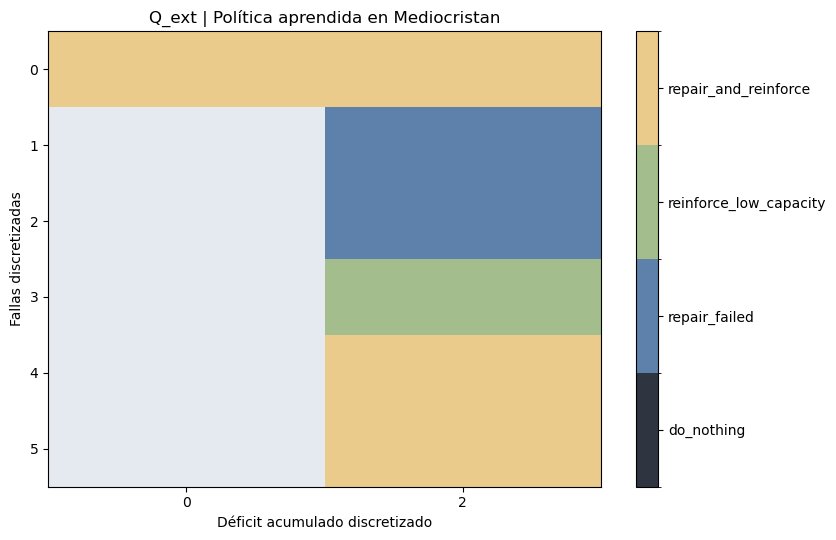


Resumen acciones Q_ext - Mediocristan
best_action
repair_and_reinforce      4
repair_failed             2
reinforce_low_capacity    1
Name: count, dtype: int64


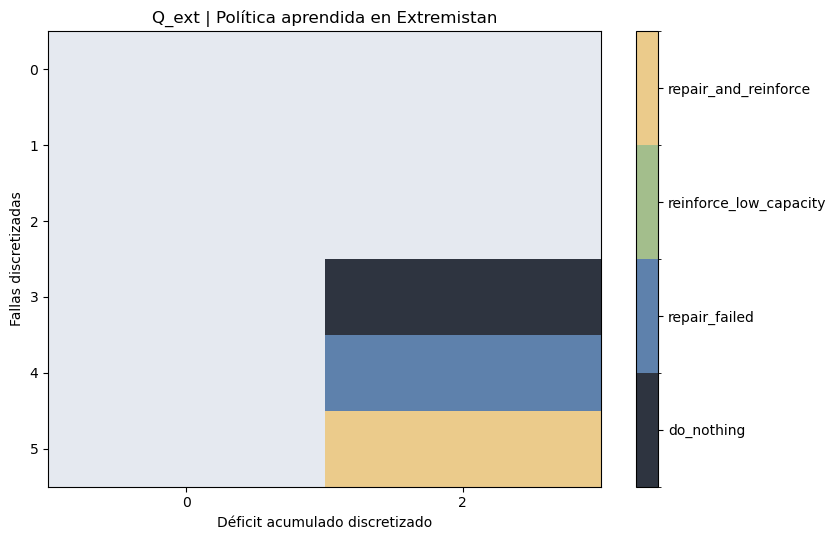


Resumen acciones Q_ext - Extremistan
best_action
do_nothing              1
repair_failed           1
repair_and_reinforce    1
Name: count, dtype: int64


In [73]:
for Q_table, name in [
    (Q_mix, "Q_mix"),
    (Q_med, "Q_med"),
    (Q_ext, "Q_ext")
]:

    # Mediocristan
    plot_q_heatmap(
        Q=Q_table,
        policy_name=name,
        crisis_value=0,
        budget_bin=2,
        reinforced_bin=0
    )

    # Extremistan
    plot_q_heatmap(
        Q=Q_table,
        policy_name=name,
        crisis_value=1,
        budget_bin=2,
        reinforced_bin=0
    )